In [1]:
import sys
from pathlib import Path

def find_project_root(markers=("src", "Data", "Notebooks")):
    current_path = Path.cwd().resolve()

    for path in [current_path] + list(current_path.parents):
        has_all_markers = all((path / marker).exists() for marker in markers)
        if has_all_markers:
            return path

    raise RuntimeError(f"Project root could not be found from: {current_path}")

project_root = find_project_root()
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import paths as P
import pandas as pd
import re

In [2]:
import pandas as pd
import numpy as np

# Load the run-level decision profile table
run_level_coded_summary_file = P.decision_logs_tables_dir / "run_level_coded_summary.csv"

run_profiles = pd.read_csv(run_level_coded_summary_file)

print("Run-level coded summary loaded successfully")
print("Shape:", run_profiles.shape)

display(run_profiles.head())

print("\nColumns:")
for col in run_profiles.columns:
    print(col)

Run-level coded summary loaded successfully
Shape: (136, 32)


,run_id,module_code,source_folder,n_decisions,completed_run,ended_early,finalScores_budget,finalScores_reputation,finalScores_security,finalScores_morale,...,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure,decision_orientation_sum,risk_management_sum,human_element_sum,transparency_sum
0,run_1776072096396_637cd8aa2ffa98,CT4010,CT4010 Morning Decision Logs,15,True,False,282000,134,185,93,...,0.133333,0.266667,0.200000,0.133333,0.400000,0.466667,1.0,1.0,1.0,1.0
1,run_1776072124156_a8612277200c78,CT4010,CT4010 Morning Decision Logs,15,True,False,178000,91,158,80,...,0.266667,0.133333,0.266667,0.266667,0.333333,0.400000,1.0,1.0,1.0,1.0
2,run_1776072427752_42c612d92ff85,CT4010,CT4010 Morning Decision Logs,15,True,False,227000,156,200,120,...,0.266667,0.400000,0.133333,0.066667,0.466667,0.466667,1.0,1.0,1.0,1.0
3,run_1776072563293_c986b5b1022df,CT4010,CT4010 Morning Decision Logs,15,True,False,7000,56,96,89,...,0.266667,0.200000,0.266667,0.400000,0.066667,0.533333,1.0,1.0,1.0,1.0
4,run_1776072647167_c3bcf318bf4108,CT4010,CT4010 Morning Decision Logs,15,True,False,207000,87,130,86,...,0.266667,0.133333,0.333333,0.533333,0.066667,0.400000,1.0,1.0,1.0,1.0



Columns:
run_id
module_code
source_folder
n_decisions
completed_run
ended_early
finalScores_budget
finalScores_reputation
finalScores_security
finalScores_morale
decision_orientation_Explicit balancing approach
decision_orientation_Financial efficiency prioritised
decision_orientation_Governance/accountability/compliance prioritised
decision_orientation_Human/staff wellbeing prioritised
decision_orientation_Operational continuity prioritised
decision_orientation_Security/risk reduction prioritised
risk_management_Containment/defensive
risk_management_Investigative/monitoring
risk_management_Preventive/proactive
risk_management_Reactive/delayed
risk_management_Risk acceptance/tolerance
human_element_Enforcement/punitive
human_element_Neutral
human_element_Supportive/enabling
human_element_Surveillance-oriented
transparency_Concealed/quiet handling
transparency_Open/transparency-first
transparency_Selective disclosure
decision_orientation_sum
risk_management_sum
human_element_sum
transp

In [3]:
# Step 2: Basic validation before clustering

print("Total rows/runs:", len(run_profiles))
print("Unique run_id values:", run_profiles["run_id"].nunique())
print("Duplicate run_id count:", run_profiles["run_id"].duplicated().sum())

print("\nCompleted run counts:")
print(run_profiles["completed_run"].value_counts(dropna=False))

print("\nEnded early counts:")
print(run_profiles["ended_early"].value_counts(dropna=False))

print("\nNumber of decisions per run:")
print(run_profiles["n_decisions"].value_counts().sort_index())

# Identify decision-profile proportion feature columns
feature_prefixes = (
    "decision_orientation_",
    "risk_management_",
    "human_element_",
    "transparency_"
)

sum_cols = [
    "decision_orientation_sum",
    "risk_management_sum",
    "human_element_sum",
    "transparency_sum"
]

feature_cols = [
    col for col in run_profiles.columns
    if col.startswith(feature_prefixes) and col not in sum_cols
]

print("\nNumber of decision-profile features:", len(feature_cols))
print("\nFeature columns:")
for col in feature_cols:
    print(col)

# Check missing values in feature columns
print("\nMissing values in feature columns:")
print(run_profiles[feature_cols].isna().sum().sort_values(ascending=False))

# Check min and max values to make sure proportions are between 0 and 1
feature_range_check = pd.DataFrame({
    "min": run_profiles[feature_cols].min(),
    "max": run_profiles[feature_cols].max()
})

print("\nFeature min/max check:")
display(feature_range_check)

# Check validation sum columns
print("\nValidation sum columns:")
display(run_profiles[sum_cols].describe())

Total rows/runs: 136
Unique run_id values: 136
Duplicate run_id count: 0

Completed run counts:
completed_run
True     125
False     11
Name: count, dtype: int64

Ended early counts:
ended_early
False    125
True      11
Name: count, dtype: int64

Number of decisions per run:
n_decisions
10      1
11      3
12      2
13      3
14      2
15    125
Name: count, dtype: int64

Number of decision-profile features: 18

Feature columns:
decision_orientation_Explicit balancing approach
decision_orientation_Financial efficiency prioritised
decision_orientation_Governance/accountability/compliance prioritised
decision_orientation_Human/staff wellbeing prioritised
decision_orientation_Operational continuity prioritised
decision_orientation_Security/risk reduction prioritised
risk_management_Containment/defensive
risk_management_Investigative/monitoring
risk_management_Preventive/proactive
risk_management_Reactive/delayed
risk_management_Risk acceptance/tolerance
human_element_Enforcement/punitive

,min,max
decision_orientation_Explicit balancing approach,0.066667,0.800000
decision_orientation_Financial efficiency prioritised,0.000000,0.200000
decision_orientation_Governance/accountability/compliance prioritised,0.000000,0.133333
decision_orientation_Human/staff wellbeing prioritised,0.000000,0.266667
decision_orientation_Operational continuity prioritised,0.000000,0.466667
decision_orientation_Security/risk reduction prioritised,0.000000,0.900000
risk_management_Containment/defensive,0.066667,0.400000
risk_management_Investigative/monitoring,0.000000,0.400000
risk_management_Preventive/proactive,0.000000,0.600000
risk_management_Reactive/delayed,0.000000,0.266667



Validation sum columns:


,decision_orientation_sum,risk_management_sum,human_element_sum,transparency_sum
count,136.0,136.0,136.0,136.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [4]:
# Step 3: Create clean clustering dataset using decision-profile proportions only

metadata_cols = [
    "run_id",
    "module_code",
    "source_folder",
    "n_decisions",
    "completed_run",
    "ended_early",
    "finalScores_budget",
    "finalScores_reputation",
    "finalScores_security",
    "finalScores_morale"
]

sum_cols = [
    "decision_orientation_sum",
    "risk_management_sum",
    "human_element_sum",
    "transparency_sum"
]

feature_prefixes = (
    "decision_orientation_",
    "risk_management_",
    "human_element_",
    "transparency_"
)

feature_cols = [
    col for col in run_profiles.columns
    if col.startswith(feature_prefixes) and col not in sum_cols
]

X = run_profiles[feature_cols].copy()

print("Clustering dataset created")
print("Number of runs:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nSelected clustering features:")
for col in feature_cols:
    print(col)

print("\nPreview of clustering dataset:")
display(X.head())

print("\nMissing values:", X.isna().sum().sum())
print("Minimum value:", X.min().min())
print("Maximum value:", X.max().max())

Clustering dataset created
Number of runs: 136
Number of features: 18

Selected clustering features:
decision_orientation_Explicit balancing approach
decision_orientation_Financial efficiency prioritised
decision_orientation_Governance/accountability/compliance prioritised
decision_orientation_Human/staff wellbeing prioritised
decision_orientation_Operational continuity prioritised
decision_orientation_Security/risk reduction prioritised
risk_management_Containment/defensive
risk_management_Investigative/monitoring
risk_management_Preventive/proactive
risk_management_Reactive/delayed
risk_management_Risk acceptance/tolerance
human_element_Enforcement/punitive
human_element_Neutral
human_element_Supportive/enabling
human_element_Surveillance-oriented
transparency_Concealed/quiet handling
transparency_Open/transparency-first
transparency_Selective disclosure

Preview of clustering dataset:


,decision_orientation_Explicit balancing approach,decision_orientation_Financial efficiency prioritised,decision_orientation_Governance/accountability/compliance prioritised,decision_orientation_Human/staff wellbeing prioritised,decision_orientation_Operational continuity prioritised,decision_orientation_Security/risk reduction prioritised,risk_management_Containment/defensive,risk_management_Investigative/monitoring,risk_management_Preventive/proactive,risk_management_Reactive/delayed,risk_management_Risk acceptance/tolerance,human_element_Enforcement/punitive,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure
0,0.333333,0.000000,0.066667,0.000000,0.266667,0.333333,0.200000,0.200000,0.266667,0.133333,0.200000,0.400000,0.133333,0.266667,0.200000,0.133333,0.400000,0.466667
1,0.266667,0.066667,0.000000,0.000000,0.266667,0.400000,0.266667,0.133333,0.200000,0.066667,0.333333,0.333333,0.266667,0.133333,0.266667,0.266667,0.333333,0.400000
2,0.600000,0.000000,0.066667,0.066667,0.066667,0.200000,0.066667,0.266667,0.400000,0.200000,0.066667,0.200000,0.266667,0.400000,0.133333,0.066667,0.466667,0.466667
3,0.266667,0.000000,0.000000,0.200000,0.200000,0.333333,0.266667,0.200000,0.133333,0.066667,0.333333,0.266667,0.266667,0.200000,0.266667,0.400000,0.066667,0.533333
4,0.200000,0.000000,0.000000,0.133333,0.266667,0.400000,0.266667,0.200000,0.133333,0.066667,0.333333,0.266667,0.266667,0.133333,0.333333,0.533333,0.066667,0.400000



Missing values: 0
Minimum value: 0.0
Maximum value: 0.9


In [5]:
# Step 4: Scale the clustering features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=feature_cols,
    index=run_profiles.index
)

print("Scaled clustering dataset created")
print("Shape:", X_scaled.shape)

print("\nScaled feature summary:")
display(X_scaled.describe().T[["mean", "std", "min", "max"]])

print("\nPreview of scaled data:")
display(X_scaled.head())

Scaled clustering dataset created
Shape: (136, 18)

Scaled feature summary:


,mean,std,min,max
decision_orientation_Explicit balancing approach,-9.143013e-17,1.003697,-2.494756,2.113001
decision_orientation_Financial efficiency prioritised,3.918434e-17,1.003697,-0.386105,4.630192
decision_orientation_Governance/accountability/compliance prioritised,1.371452e-16,1.003697,-0.910089,2.292916
decision_orientation_Human/staff wellbeing prioritised,-1.567374e-16,1.003697,-1.143285,3.202072
decision_orientation_Operational continuity prioritised,-7.183796e-17,1.003697,-1.027946,3.817727
decision_orientation_Security/risk reduction prioritised,-1.110223e-16,1.003697,-2.058399,3.844278
risk_management_Containment/defensive,-1.551047e-16,1.003697,-1.455689,3.203506
risk_management_Investigative/monitoring,1.828603e-16,1.003697,-2.941459,2.367759
risk_management_Preventive/proactive,5.224579e-17,1.003697,-2.911566,2.679262
risk_management_Reactive/delayed,1.110223e-16,1.003697,-1.785444,2.332661



Preview of scaled data:


,decision_orientation_Explicit balancing approach,decision_orientation_Financial efficiency prioritised,decision_orientation_Governance/accountability/compliance prioritised,decision_orientation_Human/staff wellbeing prioritised,decision_orientation_Operational continuity prioritised,decision_orientation_Security/risk reduction prioritised,risk_management_Containment/defensive,risk_management_Investigative/monitoring,risk_management_Preventive/proactive,risk_management_Reactive/delayed,risk_management_Risk acceptance/tolerance,human_element_Enforcement/punitive,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure
0,-0.819208,-0.386105,0.691414,-1.143285,1.741010,0.127777,0.407989,-0.28685,-0.426753,0.273609,0.152777,0.633416,-1.031758,-0.045474,0.587197,-0.014315,0.134667,-0.131863
1,-1.238095,1.285994,-0.910089,-1.143285,1.741010,0.565013,1.339828,-1.17172,-1.047956,-0.755918,1.146268,0.064356,0.240732,-1.347365,1.602404,1.142220,-0.309160,-0.605055
2,0.856340,-0.386105,0.691414,-0.056946,-0.335707,-0.746693,-1.455689,0.59802,0.815653,1.303135,-0.840713,-1.073762,0.240732,1.256417,-0.428010,-0.592582,0.578495,-0.131863
3,-1.238095,-0.386105,-0.910089,2.115733,1.048771,0.127777,1.339828,-0.28685,-1.669159,-0.755918,1.146268,-0.504703,0.240732,-0.696419,1.602404,2.298754,-2.084470,0.341329
4,-1.656982,-0.386105,-0.910089,1.029393,1.741010,0.565013,1.339828,-0.28685,-1.669159,-0.755918,1.146268,-0.504703,0.240732,-1.347365,2.617610,3.455288,-2.084470,-0.605055


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wit

K-Means screening results:


,k,inertia,mean_silhouette,smallest_cluster_size,largest_cluster_size,cluster_sizes
0,2,1932.132007,0.329604,18,118,"{0: 118, 1: 18}"
1,3,1560.273984,0.241260,16,94,"{0: 26, 1: 94, 2: 16}"
2,4,1400.030674,0.196088,10,76,"{0: 76, 1: 10, 2: 26, 3: 24}"
3,5,1267.124878,0.164877,8,45,"{0: 35, 1: 45, 2: 22, 3: 8, 4: 26}"
4,6,1177.489979,0.153221,9,34,"{0: 34, 1: 9, 2: 24, 3: 23, 4: 21, 5: 25}"
5,7,1117.515637,0.144094,8,27,"{0: 27, 1: 27, 2: 19, 3: 21, 4: 12, 5: 22, 6: 8}"
6,8,1053.836724,0.145045,7,23,"{0: 20, 1: 18, 2: 8, 3: 19, 4: 18, 5: 23, 6: 2..."
7,9,994.233385,0.145006,5,25,"{0: 18, 1: 25, 2: 5, 3: 21, 4: 12, 5: 21, 6: 8..."
8,10,946.426257,0.146194,4,22,"{0: 13, 1: 9, 2: 17, 3: 8, 4: 22, 5: 16, 6: 9,..."


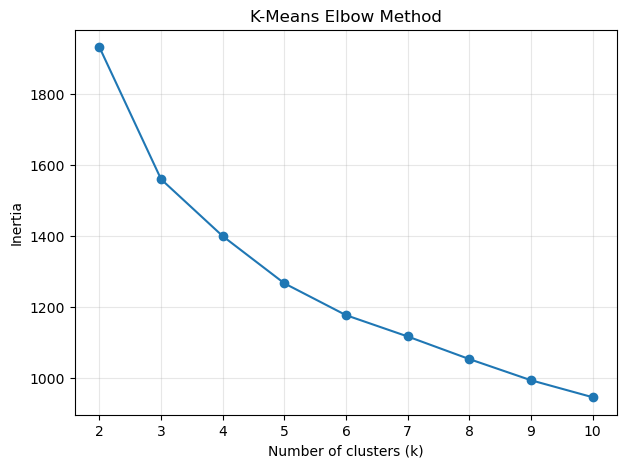

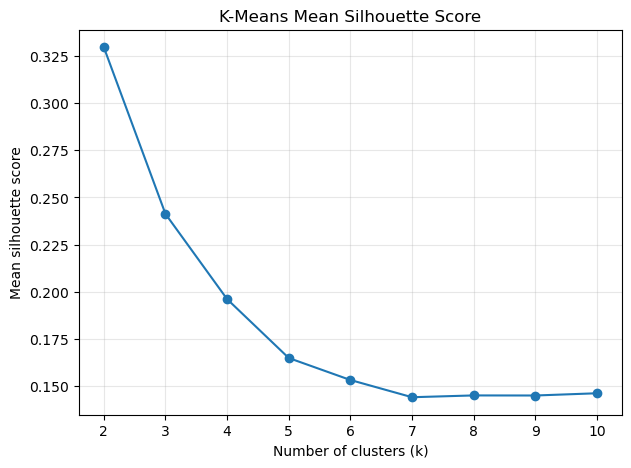

In [6]:
# Step 5: K-Means screening using inertia, mean silhouette, and cluster sizes

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

k_values = range(2, 11)

kmeans_screening_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    mean_silhouette = silhouette_score(X_scaled, labels)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    kmeans_screening_results.append({
        "k": k,
        "inertia": inertia,
        "mean_silhouette": mean_silhouette,
        "smallest_cluster_size": cluster_sizes.min(),
        "largest_cluster_size": cluster_sizes.max(),
        "cluster_sizes": cluster_sizes.to_dict()
    })

kmeans_screening_df = pd.DataFrame(kmeans_screening_results)

print("K-Means screening results:")
display(kmeans_screening_df)

# Elbow plot
plt.figure(figsize=(7, 5))
plt.plot(kmeans_screening_df["k"], kmeans_screening_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.grid(True, alpha=0.3)
plt.show()

# Mean silhouette plot
plt.figure(figsize=(7, 5))
plt.plot(kmeans_screening_df["k"], kmeans_screening_df["mean_silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean silhouette score")
plt.title("K-Means Mean Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()

c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



K-Means silhouette plot for k = 2
Mean silhouette score: 0.3296


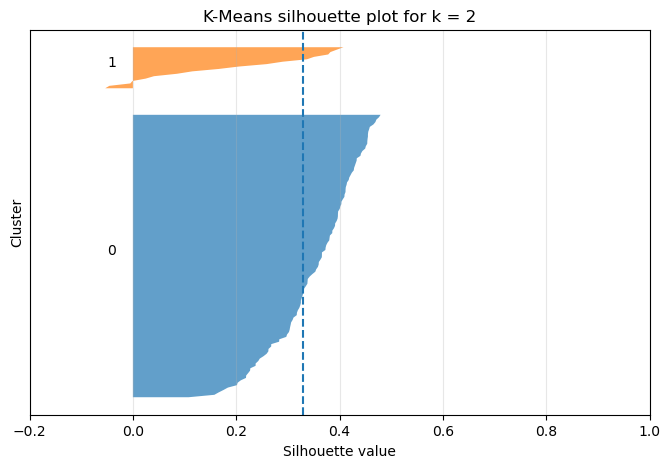


K-Means silhouette plot for k = 3
Mean silhouette score: 0.2413


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


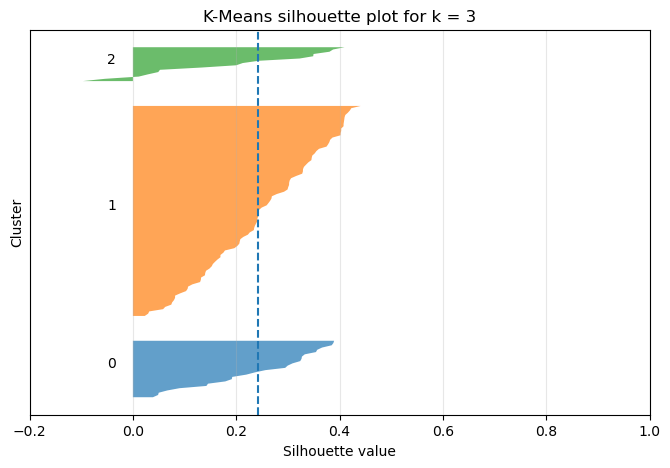

c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



K-Means silhouette plot for k = 4
Mean silhouette score: 0.1961


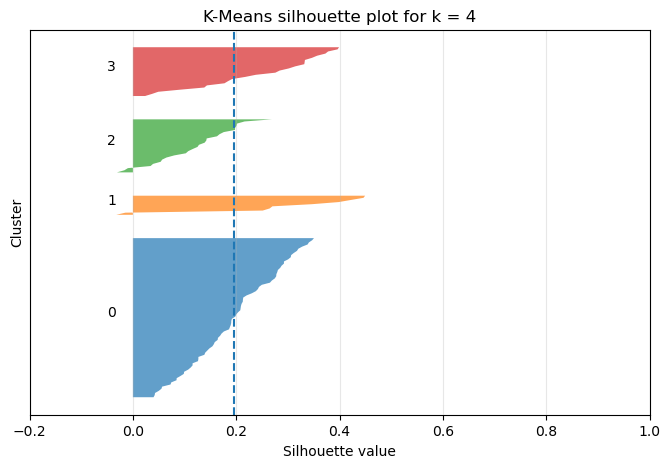

c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



K-Means silhouette plot for k = 5
Mean silhouette score: 0.1649


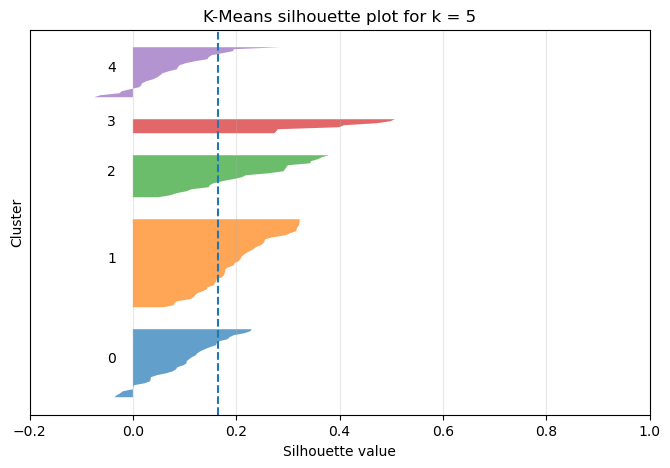


K-Means cluster-level silhouette diagnostics:


,k,cluster,cluster_size,cluster_mean_silhouette,cluster_min_silhouette,cluster_max_silhouette,negative_silhouette_count
0,2,0,118,0.351652,0.107847,0.479408,0
1,2,1,18,0.185069,-0.053524,0.407577,4
2,3,0,26,0.242672,0.038798,0.389440,0
3,3,1,94,0.250249,0.022965,0.440866,0
4,3,2,16,0.186157,-0.096861,0.409751,2
5,4,0,76,0.195913,0.039945,0.350467,0
6,4,1,10,0.280213,-0.032092,0.449489,2
7,4,2,26,0.117790,-0.030931,0.269271,3
8,4,3,24,0.246413,0.023618,0.398973,0
9,5,0,35,0.094263,-0.036083,0.229937,4


In [7]:
# Step 6: K-Means silhouette diagnostics for shortlisted k values

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidate_k_values = [2, 3, 4, 5]

kmeans_silhouette_diagnostics = []

for k in candidate_k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    
    print(f"\nK-Means silhouette plot for k = {k}")
    print(f"Mean silhouette score: {silhouette_avg:.4f}")
    
    # Cluster-level diagnostics
    for cluster_id in range(k):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        
        kmeans_silhouette_diagnostics.append({
            "k": k,
            "cluster": cluster_id,
            "cluster_size": len(cluster_silhouette_values),
            "cluster_mean_silhouette": cluster_silhouette_values.mean(),
            "cluster_min_silhouette": cluster_silhouette_values.min(),
            "cluster_max_silhouette": cluster_silhouette_values.max(),
            "negative_silhouette_count": (cluster_silhouette_values < 0).sum()
        })
    
    # Silhouette plot
    fig, ax = plt.subplots(figsize=(8, 5))
    
    y_lower = 10
    
    for cluster_id in range(k):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        cluster_silhouette_values.sort()
        
        cluster_size = cluster_silhouette_values.shape[0]
        y_upper = y_lower + cluster_size
        
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette_values,
            alpha=0.7
        )
        
        ax.text(
            -0.05,
            y_lower + 0.5 * cluster_size,
            str(cluster_id)
        )
        
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, linestyle="--")
    ax.set_title(f"K-Means silhouette plot for k = {k}")
    ax.set_xlabel("Silhouette value")
    ax.set_ylabel("Cluster")
    ax.set_xlim([-0.2, 1.0])
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)
    
    plt.show()

kmeans_silhouette_diagnostics_df = pd.DataFrame(kmeans_silhouette_diagnostics)

print("\nK-Means cluster-level silhouette diagnostics:")
display(kmeans_silhouette_diagnostics_df)

In [8]:
# Step 7: Profile K-Means with k = 3

from sklearn.cluster import KMeans
import pandas as pd

# Fit K-Means with k = 3
kmeans_k3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

kmeans_k3_labels = kmeans_k3.fit_predict(X_scaled)

# Add labels to a copy of the run-level data
kmeans_k3_profiles = run_profiles.copy()
kmeans_k3_profiles["kmeans_k3_cluster"] = kmeans_k3_labels

# Cluster sizes
print("K-Means k=3 cluster sizes:")
display(
    kmeans_k3_profiles["kmeans_k3_cluster"]
    .value_counts()
    .sort_index()
    .rename("run_count")
    .to_frame()
)

# Completed / ended early breakdown
print("\nCompleted run breakdown by cluster:")
display(
    pd.crosstab(
        kmeans_k3_profiles["kmeans_k3_cluster"],
        kmeans_k3_profiles["completed_run"],
        margins=True
    )
)

print("\nEnded early breakdown by cluster:")
display(
    pd.crosstab(
        kmeans_k3_profiles["kmeans_k3_cluster"],
        kmeans_k3_profiles["ended_early"],
        margins=True
    )
)

# Mean feature proportions by cluster
kmeans_k3_cluster_means = (
    kmeans_k3_profiles
    .groupby("kmeans_k3_cluster")[feature_cols]
    .mean()
)

print("\nK-Means k=3 cluster mean decision profiles:")
display(kmeans_k3_cluster_means)

# Compare cluster means to overall means
overall_feature_means = run_profiles[feature_cols].mean()

kmeans_k3_cluster_differences = (
    kmeans_k3_cluster_means
    .subtract(overall_feature_means, axis=1)
)

print("\nK-Means k=3 cluster differences from overall mean:")
display(kmeans_k3_cluster_differences)

# Show top features that define each cluster
for cluster_id in sorted(kmeans_k3_profiles["kmeans_k3_cluster"].unique()):
    print(f"\nTop higher-than-average features for cluster {cluster_id}:")
    display(
        kmeans_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(8)
        .to_frame("difference_from_overall")
    )
    
    print(f"\nTop lower-than-average features for cluster {cluster_id}:")
    display(
        kmeans_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=True)
        .head(8)
        .to_frame("difference_from_overall")
    )

c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means k=3 cluster sizes:


,run_count
kmeans_k3_cluster,
0,26
1,94
2,16



Completed run breakdown by cluster:


completed_run,False,True,All
kmeans_k3_cluster,,,
0,8,18,26
1,1,93,94
2,2,14,16
All,11,125,136


...

,difference_from_overall
decision_orientation_Security/risk reduction prioritised,-0.041257
transparency_Concealed/quiet handling,-0.033565
transparency_Open/transparency-first,-0.033369
risk_management_Risk acceptance/tolerance,-0.026963
decision_orientation_Operational continuity prioritised,-0.016728
human_element_Enforcement/punitive,-0.014902
decision_orientation_Financial efficiency prioritised,-0.011139
risk_management_Containment/defensive,-0.009008



Top higher-than-average features for cluster 2:


,difference_from_overall
risk_management_Risk acceptance/tolerance,0.291017
transparency_Concealed/quiet handling,0.243622
human_element_Neutral,0.159679
decision_orientation_Operational continuity prioritised,0.156692
decision_orientation_Financial efficiency prioritised,0.082122
decision_orientation_Human/staff wellbeing prioritised,0.071105
human_element_Surveillance-oriented,0.015884
decision_orientation_Governance/accountability/compliance prioritised,-0.004551



Top lower-than-average features for cluster 2:


,difference_from_overall
decision_orientation_Explicit balancing approach,-0.198488
risk_management_Preventive/proactive,-0.154292
transparency_Open/transparency-first,-0.149483
human_element_Enforcement/punitive,-0.121146
decision_orientation_Security/risk reduction prioritised,-0.106880
transparency_Selective disclosure,-0.094139
risk_management_Investigative/monitoring,-0.066804
human_element_Supportive/enabling,-0.054417


In [9]:
# Step 8: Profile K-Means with k = 4

from sklearn.cluster import KMeans
import pandas as pd

# Fit K-Means with k = 4
kmeans_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=50
)

kmeans_k4_labels = kmeans_k4.fit_predict(X_scaled)

# Add labels to a copy of the run-level data
kmeans_k4_profiles = run_profiles.copy()
kmeans_k4_profiles["kmeans_k4_cluster"] = kmeans_k4_labels

# Cluster sizes
print("K-Means k=4 cluster sizes:")
display(
    kmeans_k4_profiles["kmeans_k4_cluster"]
    .value_counts()
    .sort_index()
    .rename("run_count")
    .to_frame()
)

# Completed / ended early breakdown
print("\nCompleted run breakdown by cluster:")
display(
    pd.crosstab(
        kmeans_k4_profiles["kmeans_k4_cluster"],
        kmeans_k4_profiles["completed_run"],
        margins=True
    )
)

print("\nEnded early breakdown by cluster:")
display(
    pd.crosstab(
        kmeans_k4_profiles["kmeans_k4_cluster"],
        kmeans_k4_profiles["ended_early"],
        margins=True
    )
)

# Mean feature proportions by cluster
kmeans_k4_cluster_means = (
    kmeans_k4_profiles
    .groupby("kmeans_k4_cluster")[feature_cols]
    .mean()
)

print("\nK-Means k=4 cluster mean decision profiles:")
display(kmeans_k4_cluster_means)

# Compare cluster means to overall means
overall_feature_means = run_profiles[feature_cols].mean()

kmeans_k4_cluster_differences = (
    kmeans_k4_cluster_means
    .subtract(overall_feature_means, axis=1)
)

print("\nK-Means k=4 cluster differences from overall mean:")
display(kmeans_k4_cluster_differences)

# Show top features that define each cluster
for cluster_id in sorted(kmeans_k4_profiles["kmeans_k4_cluster"].unique()):
    print(f"\nTop higher-than-average features for cluster {cluster_id}:")
    display(
        kmeans_k4_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(8)
        .to_frame("difference_from_overall")
    )
    
    print(f"\nTop lower-than-average features for cluster {cluster_id}:")
    display(
        kmeans_k4_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=True)
        .head(8)
        .to_frame("difference_from_overall")
    )

c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means k=4 cluster sizes:


,run_count
kmeans_k4_cluster,
0,76
1,10
2,26
3,24



Completed run breakdown by cluster:


completed_run,False,True,All
kmeans_k4_cluster,,,
0,1,75,76
1,2,8,10
2,0,26,26
3,8,16,24
All,11,125,136


...

,difference_from_overall
human_element_Supportive/enabling,-0.096965
transparency_Open/transparency-first,-0.069515
risk_management_Preventive/proactive,-0.043234
decision_orientation_Human/staff wellbeing prioritised,-0.031700
risk_management_Reactive/delayed,-0.031000
decision_orientation_Explicit balancing approach,-0.027814
transparency_Selective disclosure,-0.016014
human_element_Enforcement/punitive,-0.010409



Top higher-than-average features for cluster 3:


,difference_from_overall
transparency_Open/transparency-first,0.225886
decision_orientation_Security/risk reduction prioritised,0.222886
risk_management_Preventive/proactive,0.135064
human_element_Enforcement/punitive,0.130170
risk_management_Containment/defensive,0.053079
decision_orientation_Governance/accountability/compliance prioritised,0.024018
human_element_Supportive/enabling,-0.009577
decision_orientation_Financial efficiency prioritised,-0.015394



Top lower-than-average features for cluster 3:


,difference_from_overall
transparency_Selective disclosure,-0.189517
decision_orientation_Explicit balancing approach,-0.150526
human_element_Neutral,-0.099612
risk_management_Risk acceptance/tolerance,-0.090113
risk_management_Investigative/monitoring,-0.053344
risk_management_Reactive/delayed,-0.044685
decision_orientation_Human/staff wellbeing prioritised,-0.041956
decision_orientation_Operational continuity prioritised,-0.039028


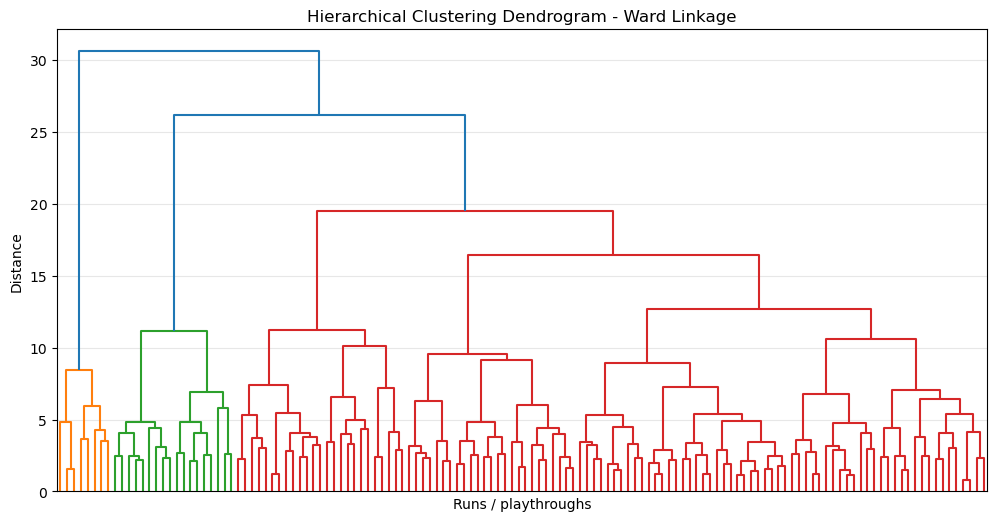

Agglomerative clustering screening results:


,k,mean_silhouette,smallest_cluster_size,largest_cluster_size,cluster_sizes
0,2,0.420008,8,128,"{0: 128, 1: 8}"
1,3,0.252388,8,110,"{0: 110, 1: 8, 2: 18}"
2,4,0.193294,8,85,"{0: 85, 1: 25, 2: 18, 3: 8}"
3,5,0.152388,8,60,"{0: 60, 1: 25, 2: 18, 3: 8, 4: 25}"
4,6,0.119814,8,31,"{0: 25, 1: 29, 2: 18, 3: 8, 4: 25, 5: 31}"
5,7,0.117950,8,31,"{0: 18, 1: 29, 2: 12, 3: 8, 4: 25, 5: 31, 6: 13}"
6,8,0.120193,8,31,"{0: 29, 1: 25, 2: 12, 3: 8, 4: 9, 5: 31, 6: 13..."
7,9,0.116965,8,31,"{0: 12, 1: 25, 2: 31, 3: 8, 4: 9, 5: 16, 6: 13..."
8,10,0.125530,5,31,"{0: 25, 1: 8, 2: 31, 3: 5, 4: 9, 5: 16, 6: 13,..."


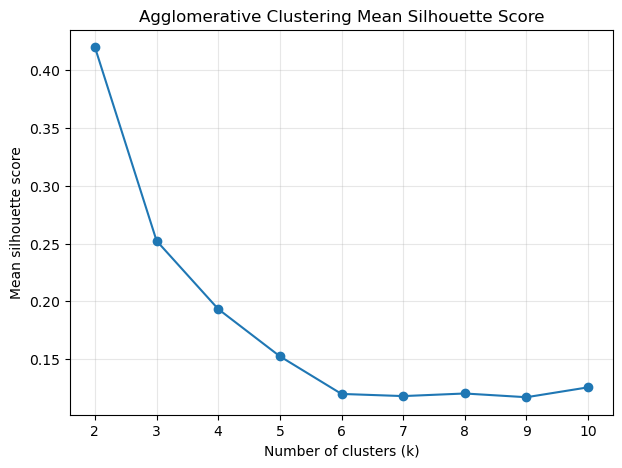

In [10]:
# Step 9: Hierarchical / Agglomerative clustering screening

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

# Create linkage matrix for dendrogram
# Ward linkage is commonly used with Euclidean distance for compact clusters
linked = linkage(X_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    no_labels=True,
    color_threshold=None
)
plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Runs / playthroughs")
plt.ylabel("Distance")
plt.grid(True, alpha=0.3)
plt.show()

# Screen k values from 2 to 10
agglo_screening_results = []

for k in range(2, 11):
    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = agglo.fit_predict(X_scaled)
    
    mean_silhouette = silhouette_score(X_scaled, labels)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    agglo_screening_results.append({
        "k": k,
        "mean_silhouette": mean_silhouette,
        "smallest_cluster_size": cluster_sizes.min(),
        "largest_cluster_size": cluster_sizes.max(),
        "cluster_sizes": cluster_sizes.to_dict()
    })

agglo_screening_df = pd.DataFrame(agglo_screening_results)

print("Agglomerative clustering screening results:")
display(agglo_screening_df)

# Mean silhouette plot
plt.figure(figsize=(7, 5))
plt.plot(
    agglo_screening_df["k"],
    agglo_screening_df["mean_silhouette"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean silhouette score")
plt.title("Agglomerative Clustering Mean Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()


Agglomerative silhouette plot for k = 3
Mean silhouette score: 0.2524


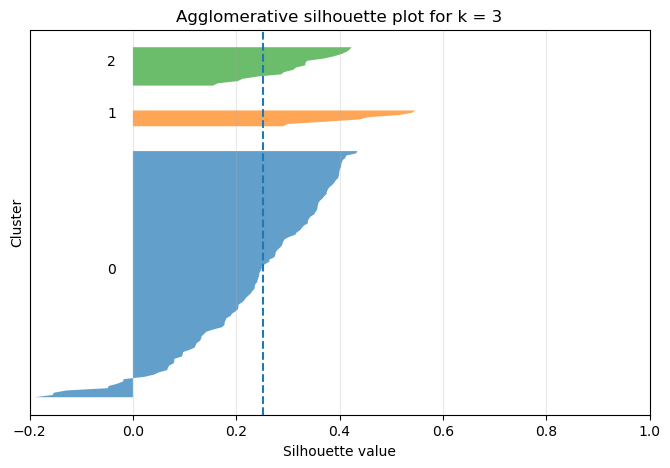


Agglomerative silhouette plot for k = 4
Mean silhouette score: 0.1933


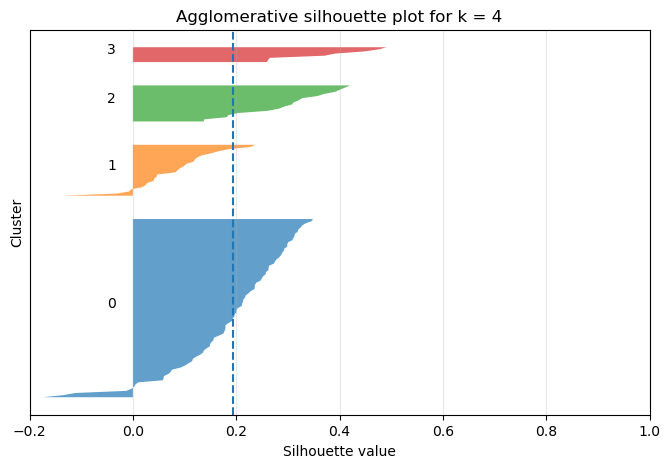


Agglomerative silhouette plot for k = 5
Mean silhouette score: 0.1524


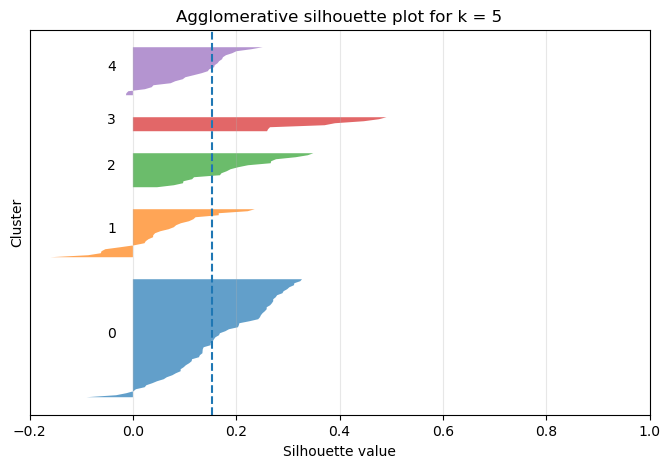


Agglomerative cluster-level silhouette diagnostics:


,k,cluster,cluster_size,cluster_mean_silhouette,cluster_min_silhouette,cluster_max_silhouette,negative_silhouette_count
0,3,0,110,0.229669,-0.189514,0.434473,9
1,3,1,8,0.432064,0.290308,0.546387,0
2,3,2,18,0.311370,0.155104,0.423023,0
3,4,0,85,0.188601,-0.173971,0.348743,5
4,4,1,25,0.079728,-0.137827,0.237751,4
5,4,2,18,0.294476,0.136901,0.420077,0
6,4,3,8,0.370398,0.259659,0.490896,0
7,5,0,60,0.166285,-0.089755,0.327271,3
8,5,1,25,0.050851,-0.159593,0.235906,6
9,5,2,18,0.194789,0.046815,0.349223,0


In [11]:
# Step 10: Agglomerative clustering silhouette diagnostics for shortlisted k values

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

agglo_candidate_k_values = [3, 4, 5]

agglo_silhouette_diagnostics = []

for k in agglo_candidate_k_values:
    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = agglo.fit_predict(X_scaled)
    
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    
    print(f"\nAgglomerative silhouette plot for k = {k}")
    print(f"Mean silhouette score: {silhouette_avg:.4f}")
    
    # Cluster-level diagnostics
    for cluster_id in range(k):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        
        agglo_silhouette_diagnostics.append({
            "k": k,
            "cluster": cluster_id,
            "cluster_size": len(cluster_silhouette_values),
            "cluster_mean_silhouette": cluster_silhouette_values.mean(),
            "cluster_min_silhouette": cluster_silhouette_values.min(),
            "cluster_max_silhouette": cluster_silhouette_values.max(),
            "negative_silhouette_count": (cluster_silhouette_values < 0).sum()
        })
    
    # Silhouette plot
    fig, ax = plt.subplots(figsize=(8, 5))
    
    y_lower = 10
    
    for cluster_id in range(k):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        cluster_silhouette_values.sort()
        
        cluster_size = cluster_silhouette_values.shape[0]
        y_upper = y_lower + cluster_size
        
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette_values,
            alpha=0.7
        )
        
        ax.text(
            -0.05,
            y_lower + 0.5 * cluster_size,
            str(cluster_id)
        )
        
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, linestyle="--")
    ax.set_title(f"Agglomerative silhouette plot for k = {k}")
    ax.set_xlabel("Silhouette value")
    ax.set_ylabel("Cluster")
    ax.set_xlim([-0.2, 1.0])
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)
    
    plt.show()

agglo_silhouette_diagnostics_df = pd.DataFrame(agglo_silhouette_diagnostics)

print("\nAgglomerative cluster-level silhouette diagnostics:")
display(agglo_silhouette_diagnostics_df)

In [12]:
# Step 11: Profile Agglomerative clustering with k = 3

from sklearn.cluster import AgglomerativeClustering
import pandas as pd

# Fit Agglomerative clustering with k = 3
agglo_k3 = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agglo_k3_labels = agglo_k3.fit_predict(X_scaled)

# Add labels to a copy of the run-level data
agglo_k3_profiles = run_profiles.copy()
agglo_k3_profiles["agglo_k3_cluster"] = agglo_k3_labels

# Cluster sizes
print("Agglomerative k=3 cluster sizes:")
display(
    agglo_k3_profiles["agglo_k3_cluster"]
    .value_counts()
    .sort_index()
    .rename("run_count")
    .to_frame()
)

# Completed / ended early breakdown
print("\nCompleted run breakdown by cluster:")
display(
    pd.crosstab(
        agglo_k3_profiles["agglo_k3_cluster"],
        agglo_k3_profiles["completed_run"],
        margins=True
    )
)

print("\nEnded early breakdown by cluster:")
display(
    pd.crosstab(
        agglo_k3_profiles["agglo_k3_cluster"],
        agglo_k3_profiles["ended_early"],
        margins=True
    )
)

# Mean feature proportions by cluster
agglo_k3_cluster_means = (
    agglo_k3_profiles
    .groupby("agglo_k3_cluster")[feature_cols]
    .mean()
)

print("\nAgglomerative k=3 cluster mean decision profiles:")
display(agglo_k3_cluster_means)

# Compare cluster means to overall means
overall_feature_means = run_profiles[feature_cols].mean()

agglo_k3_cluster_differences = (
    agglo_k3_cluster_means
    .subtract(overall_feature_means, axis=1)
)

print("\nAgglomerative k=3 cluster differences from overall mean:")
display(agglo_k3_cluster_differences)

# Show top features that define each cluster
for cluster_id in sorted(agglo_k3_profiles["agglo_k3_cluster"].unique()):
    print(f"\nTop higher-than-average features for cluster {cluster_id}:")
    display(
        agglo_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(8)
        .to_frame("difference_from_overall")
    )
    
    print(f"\nTop lower-than-average features for cluster {cluster_id}:")
    display(
        agglo_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=True)
        .head(8)
        .to_frame("difference_from_overall")
    )

Agglomerative k=3 cluster sizes:


,run_count
agglo_k3_cluster,
0,110
1,8
2,18



Completed run breakdown by cluster:


completed_run,False,True,All
agglo_k3_cluster,,,
0,2,108,110
1,1,7,8
2,8,10,18
All,11,125,136



Ended early breakdown by cluster:


...

,difference_from_overall
transparency_Open/transparency-first,-0.233938
decision_orientation_Explicit balancing approach,-0.226212
decision_orientation_Security/risk reduction prioritised,-0.224267
risk_management_Preventive/proactive,-0.216632
human_element_Enforcement/punitive,-0.196627
risk_management_Containment/defensive,-0.085395
risk_management_Investigative/monitoring,-0.071611
transparency_Selective disclosure,-0.058161



Top higher-than-average features for cluster 2:


,difference_from_overall
decision_orientation_Security/risk reduction prioritised,0.272169
transparency_Open/transparency-first,0.253697
human_element_Enforcement/punitive,0.152528
risk_management_Preventive/proactive,0.147203
risk_management_Containment/defensive,0.064746
decision_orientation_Governance/accountability/compliance prioritised,0.015022
decision_orientation_Financial efficiency prioritised,-0.015394
human_element_Surveillance-oriented,-0.022309



Top lower-than-average features for cluster 2:


,difference_from_overall
transparency_Selective disclosure,-0.209459
decision_orientation_Explicit balancing approach,-0.172056
risk_management_Risk acceptance/tolerance,-0.097356
human_element_Neutral,-0.096780
risk_management_Investigative/monitoring,-0.067625
decision_orientation_Human/staff wellbeing prioritised,-0.058480
risk_management_Reactive/delayed,-0.046968
transparency_Concealed/quiet handling,-0.044238


In [13]:
# Step 12: Profile Agglomerative clustering with k = 4

from sklearn.cluster import AgglomerativeClustering
import pandas as pd

# Fit Agglomerative clustering with k = 4
agglo_k4 = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

agglo_k4_labels = agglo_k4.fit_predict(X_scaled)

# Add labels to a copy of the run-level data
agglo_k4_profiles = run_profiles.copy()
agglo_k4_profiles["agglo_k4_cluster"] = agglo_k4_labels

# Cluster sizes
print("Agglomerative k=4 cluster sizes:")
display(
    agglo_k4_profiles["agglo_k4_cluster"]
    .value_counts()
    .sort_index()
    .rename("run_count")
    .to_frame()
)

# Completed / ended early breakdown
print("\nCompleted run breakdown by cluster:")
display(
    pd.crosstab(
        agglo_k4_profiles["agglo_k4_cluster"],
        agglo_k4_profiles["completed_run"],
        margins=True
    )
)

print("\nEnded early breakdown by cluster:")
display(
    pd.crosstab(
        agglo_k4_profiles["agglo_k4_cluster"],
        agglo_k4_profiles["ended_early"],
        margins=True
    )
)

# Mean feature proportions by cluster
agglo_k4_cluster_means = (
    agglo_k4_profiles
    .groupby("agglo_k4_cluster")[feature_cols]
    .mean()
)

print("\nAgglomerative k=4 cluster mean decision profiles:")
display(agglo_k4_cluster_means)

# Compare cluster means to overall means
overall_feature_means = run_profiles[feature_cols].mean()

agglo_k4_cluster_differences = (
    agglo_k4_cluster_means
    .subtract(overall_feature_means, axis=1)
)

print("\nAgglomerative k=4 cluster differences from overall mean:")
display(agglo_k4_cluster_differences)

# Show top features that define each cluster
for cluster_id in sorted(agglo_k4_profiles["agglo_k4_cluster"].unique()):
    print(f"\nTop higher-than-average features for cluster {cluster_id}:")
    display(
        agglo_k4_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(8)
        .to_frame("difference_from_overall")
    )
    
    print(f"\nTop lower-than-average features for cluster {cluster_id}:")
    display(
        agglo_k4_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=True)
        .head(8)
        .to_frame("difference_from_overall")
    )

Agglomerative k=4 cluster sizes:


,run_count
agglo_k4_cluster,
0,85
1,25
2,18
3,8



Completed run breakdown by cluster:


completed_run,False,True,All
agglo_k4_cluster,,,
0,1,84,85
1,1,24,25
2,8,10,18
3,1,7,8
All,11,125,136



Ended early breakdown by cluster:


...

,difference_from_overall
transparency_Selective disclosure,-0.209459
decision_orientation_Explicit balancing approach,-0.172056
risk_management_Risk acceptance/tolerance,-0.097356
human_element_Neutral,-0.096780
risk_management_Investigative/monitoring,-0.067625
decision_orientation_Human/staff wellbeing prioritised,-0.058480
risk_management_Reactive/delayed,-0.046968
transparency_Concealed/quiet handling,-0.044238



Top higher-than-average features for cluster 3:


,difference_from_overall
risk_management_Risk acceptance/tolerance,0.420504
transparency_Concealed/quiet handling,0.292100
human_element_Neutral,0.237724
decision_orientation_Operational continuity prioritised,0.223919
decision_orientation_Human/staff wellbeing prioritised,0.119422
decision_orientation_Financial efficiency prioritised,0.111689
decision_orientation_Governance/accountability/compliance prioritised,-0.004551
human_element_Surveillance-oriented,-0.009357



Top lower-than-average features for cluster 3:


,difference_from_overall
transparency_Open/transparency-first,-0.233938
decision_orientation_Explicit balancing approach,-0.226212
decision_orientation_Security/risk reduction prioritised,-0.224267
risk_management_Preventive/proactive,-0.216632
human_element_Enforcement/punitive,-0.196627
risk_management_Containment/defensive,-0.085395
risk_management_Investigative/monitoring,-0.071611
transparency_Selective disclosure,-0.058161


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

Gaussian Mixture Model screening results:


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

,k,aic,bic,mean_silhouette,smallest_cluster_size,largest_cluster_size,mean_assignment_confidence,min_assignment_confidence,cluster_sizes
0,2,-3215.362790,-2111.466588,0.263662,25,111,0.999972,0.997879,"{0: 111, 1: 25}"
1,3,-3498.892545,-1841.591915,0.090004,12,109,1.000000,1.000000,"{0: 109, 1: 15, 2: 12}"
2,4,-3921.180959,-1710.475901,0.041199,9,100,0.997501,0.680135,"{0: 100, 1: 17, 2: 9, 3: 10}"
3,5,-4417.478495,-1653.369008,0.038251,8,96,1.000000,0.999992,"{0: 11, 1: 8, 2: 96, 3: 8, 4: 13}"
4,6,-4377.546513,-1060.032599,0.041004,8,82,0.999995,0.999340,"{0: 82, 1: 12, 2: 14, 3: 11, 4: 8, 5: 9}"
5,7,-4682.433478,-811.515135,0.122781,8,48,0.999993,0.999420,"{0: 48, 1: 29, 2: 18, 3: 11, 4: 12, 5: 8, 6: 10}"
6,8,-4459.199126,-34.876354,0.118521,6,44,0.999995,0.999774,"{0: 6, 1: 12, 2: 8, 3: 11, 4: 17, 5: 44, 6: 19..."
7,9,-4699.937695,277.789505,0.131578,4,42,0.999980,0.997969,"{0: 11, 1: 42, 2: 20, 3: 14, 4: 4, 5: 6, 6: 22..."
8,10,-4556.120440,975.011188,0.115290,5,42,1.000000,0.999988,"{0: 42, 1: 6, 2: 8, 3: 16, 4: 12, 5: 5, 6: 13,..."


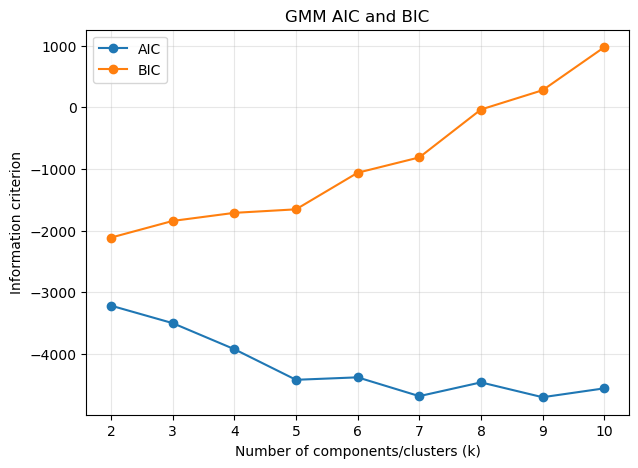

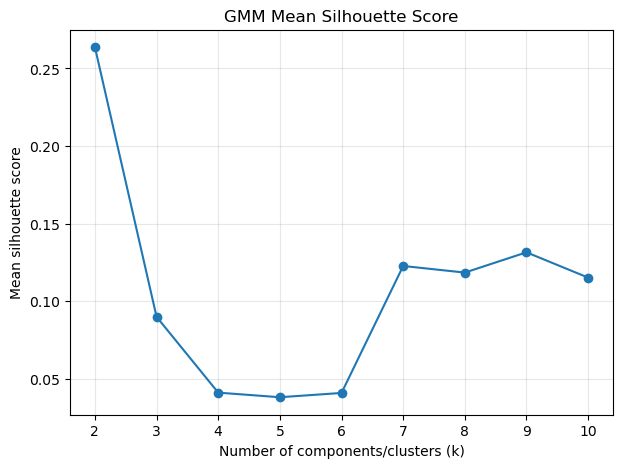

In [14]:
# Step 13: Gaussian Mixture Model screening using AIC, BIC, silhouette, and cluster sizes

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gmm_screening_results = []

# Test k = 2 to 10
# For this first pass, use covariance_type="full"
# If full covariance looks unstable later, can compare other covariance types.
for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=20
    )
    
    labels = gmm.fit_predict(X_scaled)
    probabilities = gmm.predict_proba(X_scaled)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    mean_silhouette = silhouette_score(X_scaled, labels)
    
    # Assignment confidence: how confidently each run belongs to its assigned cluster
    max_assignment_probability = probabilities.max(axis=1)
    
    gmm_screening_results.append({
        "k": k,
        "aic": gmm.aic(X_scaled),
        "bic": gmm.bic(X_scaled),
        "mean_silhouette": mean_silhouette,
        "smallest_cluster_size": cluster_sizes.min(),
        "largest_cluster_size": cluster_sizes.max(),
        "mean_assignment_confidence": max_assignment_probability.mean(),
        "min_assignment_confidence": max_assignment_probability.min(),
        "cluster_sizes": cluster_sizes.to_dict()
    })

gmm_screening_df = pd.DataFrame(gmm_screening_results)

print("Gaussian Mixture Model screening results:")
display(gmm_screening_df)

# Plot AIC and BIC
plt.figure(figsize=(7, 5))
plt.plot(gmm_screening_df["k"], gmm_screening_df["aic"], marker="o", label="AIC")
plt.plot(gmm_screening_df["k"], gmm_screening_df["bic"], marker="o", label="BIC")
plt.xlabel("Number of components/clusters (k)")
plt.ylabel("Information criterion")
plt.title("GMM AIC and BIC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot mean silhouette
plt.figure(figsize=(7, 5))
plt.plot(gmm_screening_df["k"], gmm_screening_df["mean_silhouette"], marker="o")
plt.xlabel("Number of components/clusters (k)")
plt.ylabel("Mean silhouette score")
plt.title("GMM Mean Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Step 14: Profile Gaussian Mixture Model with k = 3

from sklearn.mixture import GaussianMixture
import pandas as pd
import numpy as np

# Fit GMM with k = 3
gmm_k3 = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=20
)

gmm_k3_labels = gmm_k3.fit_predict(X_scaled)
gmm_k3_probabilities = gmm_k3.predict_proba(X_scaled)

# Add labels and assignment confidence to a copy of the run-level data
gmm_k3_profiles = run_profiles.copy()
gmm_k3_profiles["gmm_k3_cluster"] = gmm_k3_labels
gmm_k3_profiles["gmm_k3_assignment_confidence"] = gmm_k3_probabilities.max(axis=1)

# Cluster sizes
print("GMM k=3 cluster sizes:")
display(
    gmm_k3_profiles["gmm_k3_cluster"]
    .value_counts()
    .sort_index()
    .rename("run_count")
    .to_frame()
)

# Completed / ended early breakdown
print("\nCompleted run breakdown by cluster:")
display(
    pd.crosstab(
        gmm_k3_profiles["gmm_k3_cluster"],
        gmm_k3_profiles["completed_run"],
        margins=True
    )
)

print("\nEnded early breakdown by cluster:")
display(
    pd.crosstab(
        gmm_k3_profiles["gmm_k3_cluster"],
        gmm_k3_profiles["ended_early"],
        margins=True
    )
)

# Assignment confidence summary
print("\nGMM k=3 assignment confidence by cluster:")
display(
    gmm_k3_profiles
    .groupby("gmm_k3_cluster")["gmm_k3_assignment_confidence"]
    .describe()
)

# Mean feature proportions by cluster
gmm_k3_cluster_means = (
    gmm_k3_profiles
    .groupby("gmm_k3_cluster")[feature_cols]
    .mean()
)

print("\nGMM k=3 cluster mean decision profiles:")
display(gmm_k3_cluster_means)

# Compare cluster means to overall means
overall_feature_means = run_profiles[feature_cols].mean()

gmm_k3_cluster_differences = (
    gmm_k3_cluster_means
    .subtract(overall_feature_means, axis=1)
)

print("\nGMM k=3 cluster differences from overall mean:")
display(gmm_k3_cluster_differences)

# Show top features that define each cluster
for cluster_id in sorted(gmm_k3_profiles["gmm_k3_cluster"].unique()):
    print(f"\nTop higher-than-average features for cluster {cluster_id}:")
    display(
        gmm_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(8)
        .to_frame("difference_from_overall")
    )
    
    print(f"\nTop lower-than-average features for cluster {cluster_id}:")
    display(
        gmm_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=True)
        .head(8)
        .to_frame("difference_from_overall")
    )

GMM k=3 cluster sizes:


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

,run_count
gmm_k3_cluster,
0,109
1,15
2,12



Completed run breakdown by cluster:


completed_run,False,True,All
gmm_k3_cluster,,,
0,9,100,109
1,2,13,15
2,0,12,12
All,11,125,136


...

,difference_from_overall
decision_orientation_Explicit balancing approach,-0.207473
transparency_Open/transparency-first,-0.165242
risk_management_Preventive/proactive,-0.161525
human_element_Enforcement/punitive,-0.125281
decision_orientation_Security/risk reduction prioritised,-0.106415
transparency_Selective disclosure,-0.090287
risk_management_Investigative/monitoring,-0.065372
human_element_Supportive/enabling,-0.062179



Top higher-than-average features for cluster 2:


,difference_from_overall
human_element_Neutral,0.075224
transparency_Concealed/quiet handling,0.048350
decision_orientation_Financial efficiency prioritised,0.034606
human_element_Surveillance-oriented,0.033005
risk_management_Risk acceptance/tolerance,0.031615
risk_management_Reactive/delayed,0.028829
risk_management_Investigative/monitoring,0.022833
decision_orientation_Governance/accountability/compliance prioritised,0.012115



Top lower-than-average features for cluster 2:


,difference_from_overall
human_element_Enforcement/punitive,-0.070238
risk_management_Preventive/proactive,-0.045799
human_element_Supportive/enabling,-0.037991
risk_management_Containment/defensive,-0.037478
decision_orientation_Security/risk reduction prioritised,-0.036073
transparency_Selective disclosure,-0.029689
transparency_Open/transparency-first,-0.018661
decision_orientation_Operational continuity prioritised,-0.010108


Spectral Clustering screening results:


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: User

,k,mean_silhouette,smallest_cluster_size,largest_cluster_size,cluster_sizes
0,2,0.205264,23,113,"{0: 113, 1: 23}"
1,3,0.248174,9,105,"{0: 105, 1: 9, 2: 22}"
2,4,0.148111,9,53,"{0: 52, 1: 9, 2: 22, 3: 53}"
3,5,0.161397,9,44,"{0: 44, 1: 29, 2: 9, 3: 33, 4: 21}"
4,6,0.145426,9,30,"{0: 24, 1: 30, 2: 17, 3: 29, 4: 9, 5: 27}"
5,7,0.142892,9,28,"{0: 21, 1: 28, 2: 18, 3: 16, 4: 23, 5: 21, 6: 9}"
6,8,0.134342,9,30,"{0: 21, 1: 30, 2: 16, 3: 13, 4: 16, 5: 9, 6: 2..."
7,9,0.122191,9,23,"{0: 9, 1: 12, 2: 15, 3: 20, 4: 23, 5: 9, 6: 13..."
8,10,0.131412,9,23,"{0: 17, 1: 12, 2: 16, 3: 9, 4: 9, 5: 14, 6: 9,..."


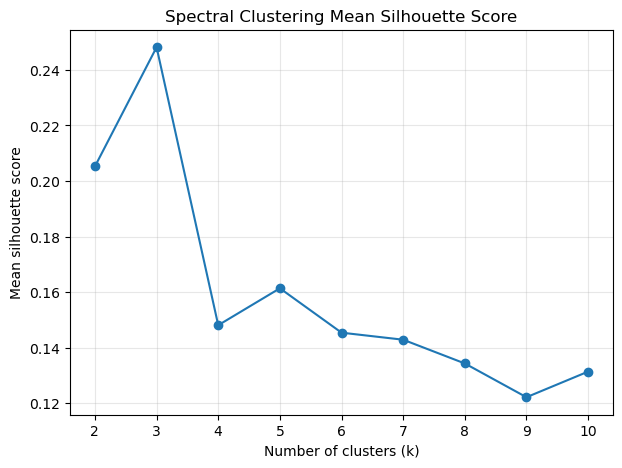

In [16]:
# Step 15: Spectral Clustering screening

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

spectral_screening_results = []

for k in range(2, 11):
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=10,
        random_state=42
    )
    
    labels = spectral.fit_predict(X_scaled)
    
    mean_silhouette = silhouette_score(X_scaled, labels)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    spectral_screening_results.append({
        "k": k,
        "mean_silhouette": mean_silhouette,
        "smallest_cluster_size": cluster_sizes.min(),
        "largest_cluster_size": cluster_sizes.max(),
        "cluster_sizes": cluster_sizes.to_dict()
    })

spectral_screening_df = pd.DataFrame(spectral_screening_results)

print("Spectral Clustering screening results:")
display(spectral_screening_df)

plt.figure(figsize=(7, 5))
plt.plot(
    spectral_screening_df["k"],
    spectral_screening_df["mean_silhouette"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean silhouette score")
plt.title("Spectral Clustering Mean Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()


Spectral Clustering silhouette plot for k = 3
Mean silhouette score: 0.2482


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


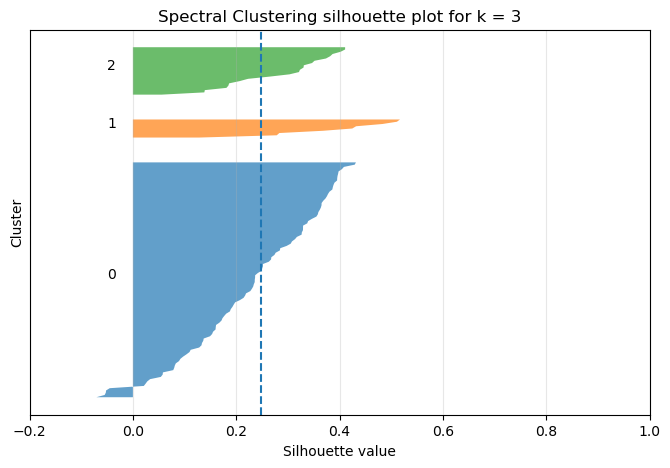

c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Spectral Clustering silhouette plot for k = 5
Mean silhouette score: 0.1614


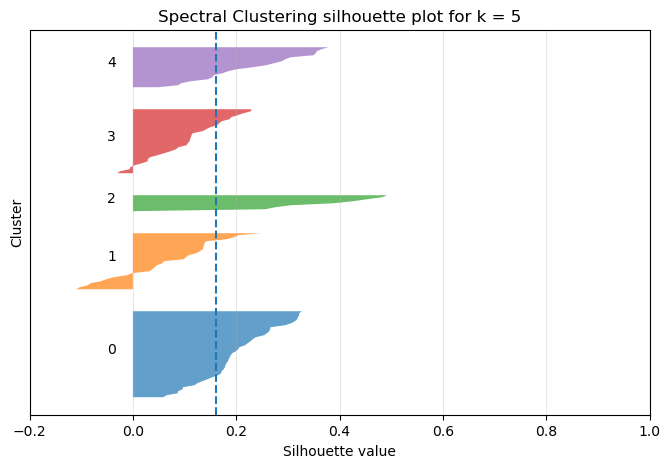


Spectral Clustering cluster-level silhouette diagnostics:


,k,cluster,cluster_size,cluster_mean_silhouette,cluster_min_silhouette,cluster_max_silhouette,negative_silhouette_count
0,3,0,105,0.229270,-0.070617,0.431678,5
1,3,1,9,0.380688,0.128499,0.516932,0
2,3,2,22,0.284185,0.055123,0.410797,0
3,5,0,44,0.202370,0.058356,0.326762,0
4,5,1,29,0.062388,-0.109905,0.247928,9
5,5,2,9,0.341653,-0.007128,0.491895,1
6,5,3,33,0.101509,-0.030295,0.229091,4
7,5,4,21,0.229136,0.049126,0.378459,0


In [17]:
# Step 16: Spectral Clustering silhouette diagnostics for shortlisted k values

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

spectral_candidate_k_values = [3, 5]

spectral_silhouette_diagnostics = []

for k in spectral_candidate_k_values:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=10,
        random_state=42
    )
    
    labels = spectral.fit_predict(X_scaled)
    
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    
    print(f"\nSpectral Clustering silhouette plot for k = {k}")
    print(f"Mean silhouette score: {silhouette_avg:.4f}")
    
    for cluster_id in range(k):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        
        spectral_silhouette_diagnostics.append({
            "k": k,
            "cluster": cluster_id,
            "cluster_size": len(cluster_silhouette_values),
            "cluster_mean_silhouette": cluster_silhouette_values.mean(),
            "cluster_min_silhouette": cluster_silhouette_values.min(),
            "cluster_max_silhouette": cluster_silhouette_values.max(),
            "negative_silhouette_count": (cluster_silhouette_values < 0).sum()
        })
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    y_lower = 10
    
    for cluster_id in range(k):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        cluster_silhouette_values.sort()
        
        cluster_size = cluster_silhouette_values.shape[0]
        y_upper = y_lower + cluster_size
        
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette_values,
            alpha=0.7
        )
        
        ax.text(
            -0.05,
            y_lower + 0.5 * cluster_size,
            str(cluster_id)
        )
        
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, linestyle="--")
    ax.set_title(f"Spectral Clustering silhouette plot for k = {k}")
    ax.set_xlabel("Silhouette value")
    ax.set_ylabel("Cluster")
    ax.set_xlim([-0.2, 1.0])
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)
    
    plt.show()

spectral_silhouette_diagnostics_df = pd.DataFrame(spectral_silhouette_diagnostics)

print("\nSpectral Clustering cluster-level silhouette diagnostics:")
display(spectral_silhouette_diagnostics_df)

In [18]:
# Step 17: Profile Spectral Clustering with k = 3

from sklearn.cluster import SpectralClustering
import pandas as pd

# Fit Spectral Clustering with k = 3
spectral_k3 = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)

spectral_k3_labels = spectral_k3.fit_predict(X_scaled)

# Add labels to a copy of the run-level data
spectral_k3_profiles = run_profiles.copy()
spectral_k3_profiles["spectral_k3_cluster"] = spectral_k3_labels

# Cluster sizes
print("Spectral k=3 cluster sizes:")
display(
    spectral_k3_profiles["spectral_k3_cluster"]
    .value_counts()
    .sort_index()
    .rename("run_count")
    .to_frame()
)

# Completed / ended early breakdown
print("\nCompleted run breakdown by cluster:")
display(
    pd.crosstab(
        spectral_k3_profiles["spectral_k3_cluster"],
        spectral_k3_profiles["completed_run"],
        margins=True
    )
)

print("\nEnded early breakdown by cluster:")
display(
    pd.crosstab(
        spectral_k3_profiles["spectral_k3_cluster"],
        spectral_k3_profiles["ended_early"],
        margins=True
    )
)

# Mean feature proportions by cluster
spectral_k3_cluster_means = (
    spectral_k3_profiles
    .groupby("spectral_k3_cluster")[feature_cols]
    .mean()
)

print("\nSpectral k=3 cluster mean decision profiles:")
display(spectral_k3_cluster_means)

# Compare cluster means to overall means
overall_feature_means = run_profiles[feature_cols].mean()

spectral_k3_cluster_differences = (
    spectral_k3_cluster_means
    .subtract(overall_feature_means, axis=1)
)

print("\nSpectral k=3 cluster differences from overall mean:")
display(spectral_k3_cluster_differences)

# Show top features that define each cluster
for cluster_id in sorted(spectral_k3_profiles["spectral_k3_cluster"].unique()):
    print(f"\nTop higher-than-average features for cluster {cluster_id}:")
    display(
        spectral_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=False)
        .head(8)
        .to_frame("difference_from_overall")
    )
    
    print(f"\nTop lower-than-average features for cluster {cluster_id}:")
    display(
        spectral_k3_cluster_differences
        .loc[cluster_id]
        .sort_values(ascending=True)
        .head(8)
        .to_frame("difference_from_overall")
    )

Spectral k=3 cluster sizes:


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,run_count
spectral_k3_cluster,
0,105
1,9
2,22



Completed run breakdown by cluster:


completed_run,False,True,All
spectral_k3_cluster,,,
0,1,104,105
1,2,7,9
2,8,14,22
All,11,125,136


...

,difference_from_overall
decision_orientation_Explicit balancing approach,-0.244054
transparency_Open/transparency-first,-0.207407
risk_management_Preventive/proactive,-0.201639
decision_orientation_Security/risk reduction prioritised,-0.182939
human_element_Enforcement/punitive,-0.176791
risk_management_Investigative/monitoring,-0.079731
transparency_Selective disclosure,-0.071427
risk_management_Containment/defensive,-0.069244



Top higher-than-average features for cluster 2:


,difference_from_overall
decision_orientation_Security/risk reduction prioritised,0.241377
transparency_Open/transparency-first,0.235491
risk_management_Preventive/proactive,0.142415
human_element_Enforcement/punitive,0.132227
risk_management_Containment/defensive,0.052220
decision_orientation_Governance/accountability/compliance prioritised,0.023585
human_element_Supportive/enabling,-0.013055
decision_orientation_Financial efficiency prioritised,-0.015394



Top lower-than-average features for cluster 2:


,difference_from_overall
transparency_Selective disclosure,-0.195966
decision_orientation_Explicit balancing approach,-0.164479
human_element_Neutral,-0.098840
risk_management_Risk acceptance/tolerance,-0.091079
risk_management_Investigative/monitoring,-0.056228
decision_orientation_Human/staff wellbeing prioritised,-0.048483
risk_management_Reactive/delayed,-0.047328
transparency_Concealed/quiet handling,-0.039525


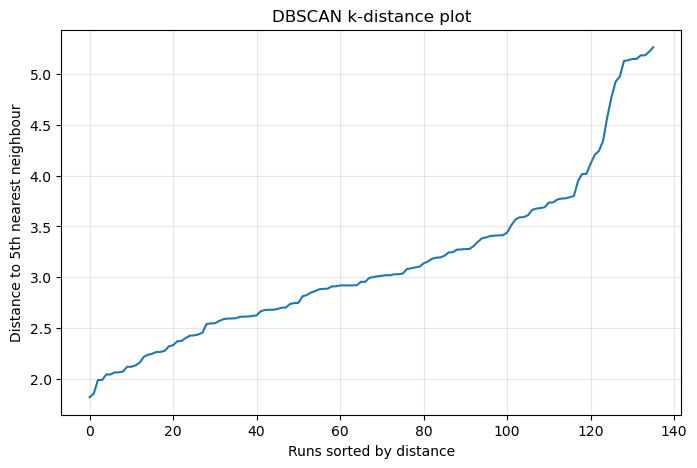

k-distance quantiles:


,distance
0.50,2.998083
0.60,3.154494
0.70,3.388506
0.75,3.525837
0.80,3.681692
0.85,3.785036
0.90,4.224864
0.95,5.131302


In [19]:
# Step 18: DBSCAN preparation using k-distance plot

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# DBSCAN needs two main settings:
# eps = neighbourhood distance
# min_samples = minimum points needed to form a dense area

# Start with min_samples = 5 as a first simple test
min_samples = 5

nearest_neighbors = NearestNeighbors(n_neighbors=min_samples)
nearest_neighbors.fit(X_scaled)

distances, indices = nearest_neighbors.kneighbors(X_scaled)

# Use the distance to the kth nearest neighbour
k_distances = np.sort(distances[:, min_samples - 1])

# Plot k-distance curve
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Runs sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbour")
plt.title("DBSCAN k-distance plot")
plt.grid(True, alpha=0.3)
plt.show()

# Print useful quantiles to help choose eps values
distance_quantiles = pd.Series(k_distances).quantile(
    [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
)

print("k-distance quantiles:")
display(distance_quantiles.to_frame("distance"))

In [20]:
# Step 19: DBSCAN screening using selected eps values

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

dbscan_eps_values = [3.0, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3, 4.5, 5.0]

dbscan_screening_results = []

for eps in dbscan_eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    # DBSCAN labels noise as -1
    n_noise = (labels == -1).sum()
    noise_percent = (n_noise / len(labels)) * 100
    
    # Number of real clusters, excluding noise
    cluster_labels = sorted(set(labels) - {-1})
    n_clusters = len(cluster_labels)
    
    # Cluster sizes excluding noise
    cluster_sizes = pd.Series(labels[labels != -1]).value_counts().sort_index()
    
    # Silhouette including noise as a label, only if there are at least 2 labels
    if len(set(labels)) >= 2:
        silhouette_all = silhouette_score(X_scaled, labels)
    else:
        silhouette_all = np.nan
    
    # Silhouette excluding noise, only if at least 2 non-noise clusters exist
    non_noise_mask = labels != -1
    
    if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
        silhouette_without_noise = silhouette_score(
            X_scaled[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        silhouette_without_noise = np.nan
    
    dbscan_screening_results.append({
        "eps": eps,
        "min_samples": 5,
        "n_clusters_excluding_noise": n_clusters,
        "noise_count": n_noise,
        "noise_percent": noise_percent,
        "smallest_cluster_size": cluster_sizes.min() if n_clusters > 0 else np.nan,
        "largest_cluster_size": cluster_sizes.max() if n_clusters > 0 else np.nan,
        "silhouette_including_noise": silhouette_all,
        "silhouette_without_noise": silhouette_without_noise,
        "cluster_sizes_excluding_noise": cluster_sizes.to_dict()
    })

dbscan_screening_df = pd.DataFrame(dbscan_screening_results)

print("DBSCAN screening results:")
display(dbscan_screening_df)

DBSCAN screening results:


,eps,min_samples,n_clusters_excluding_noise,noise_count,noise_percent,smallest_cluster_size,largest_cluster_size,silhouette_including_noise,silhouette_without_noise,cluster_sizes_excluding_noise
0,3.0,5,2,38,27.941176,4,94,0.063477,0.124452,"{0: 94, 1: 4}"
1,3.3,5,1,24,17.647059,112,112,0.282578,NaN,{0: 112}
2,3.5,5,1,21,15.441176,115,115,0.308762,NaN,{0: 115}
3,3.7,5,1,15,11.029412,121,121,0.357733,NaN,{0: 121}
4,3.9,5,1,11,8.088235,125,125,0.381896,NaN,{0: 125}
5,4.1,5,1,10,7.352941,126,126,0.386135,NaN,{0: 126}
6,4.3,5,1,7,5.147059,129,129,0.373753,NaN,{0: 129}
7,4.5,5,1,1,0.735294,135,135,0.466222,NaN,{0: 135}
8,5.0,5,1,1,0.735294,135,135,0.466222,NaN,{0: 135}


In [21]:
# Step 20: Create summary comparison table for main clustering methods

method_comparison = pd.DataFrame([
    {
        "method": "K-Means",
        "candidate_solution": "k=3",
        "mean_silhouette": 0.241260,
        "cluster_sizes": "26, 94, 16",
        "interpretability": "Good",
        "main_comment": "Clear three-profile structure: security-first, balanced/selective, risk-accepting/operational"
    },
    {
        "method": "K-Means",
        "candidate_solution": "k=4",
        "mean_silhouette": 0.196088,
        "cluster_sizes": "76, 10, 26, 24",
        "interpretability": "Moderate",
        "main_comment": "More detailed, but one cluster is less clearly defined"
    },
    {
        "method": "Agglomerative",
        "candidate_solution": "k=3",
        "mean_silhouette": 0.252388,
        "cluster_sizes": "110, 8, 18",
        "interpretability": "Moderate",
        "main_comment": "Similar three-profile structure, but very imbalanced"
    },
    {
        "method": "Agglomerative",
        "candidate_solution": "k=4",
        "mean_silhouette": 0.193294,
        "cluster_sizes": "85, 25, 18, 8",
        "interpretability": "Moderate",
        "main_comment": "Useful detail, but one softer cluster is harder to explain"
    },
    {
        "method": "Gaussian Mixture Model",
        "candidate_solution": "k=3",
        "mean_silhouette": 0.090004,
        "cluster_sizes": "109, 15, 12",
        "interpretability": "Weak",
        "main_comment": "One large general cluster and weak separation; not a strong solution"
    },
    {
        "method": "Spectral Clustering",
        "candidate_solution": "k=3",
        "mean_silhouette": 0.248174,
        "cluster_sizes": "105, 9, 22",
        "interpretability": "Moderate",
        "main_comment": "Supports the same broad three-profile structure, but imbalanced"
    },
    {
        "method": "DBSCAN",
        "candidate_solution": "eps range tested",
        "mean_silhouette": None,
        "cluster_sizes": "Mostly one cluster + noise",
        "interpretability": "Weak",
        "main_comment": "Did not identify useful density-based decision-profile groups"
    }
])

print("Main clustering method comparison:")
display(method_comparison)

Main clustering method comparison:


,method,candidate_solution,mean_silhouette,cluster_sizes,interpretability,main_comment
0,K-Means,k=3,0.241260,"26, 94, 16",Good,"Clear three-profile structure: security-first,..."
1,K-Means,k=4,0.196088,"76, 10, 26, 24",Moderate,"More detailed, but one cluster is less clearly..."
2,Agglomerative,k=3,0.252388,"110, 8, 18",Moderate,"Similar three-profile structure, but very imba..."
3,Agglomerative,k=4,0.193294,"85, 25, 18, 8",Moderate,"Useful detail, but one softer cluster is harde..."
4,Gaussian Mixture Model,k=3,0.090004,"109, 15, 12",Weak,One large general cluster and weak separation;...
5,Spectral Clustering,k=3,0.248174,"105, 9, 22",Moderate,Supports the same broad three-profile structur...
6,DBSCAN,eps range tested,NaN,Mostly one cluster + noise,Weak,Did not identify useful density-based decision...


In [22]:
# Step 21: Create final working K-Means k=3 cluster profile table

from sklearn.cluster import KMeans
import pandas as pd

# Refit K-Means k=3 as the current working solution
final_kmeans_k3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

final_kmeans_k3_labels = final_kmeans_k3.fit_predict(X_scaled)

# Add cluster labels to run-level data
final_clustered_runs = run_profiles.copy()
final_clustered_runs["kmeans_k3_cluster"] = final_kmeans_k3_labels

# Add working descriptive labels based on earlier interpretation
cluster_label_map = {
    0: "Security-first / proactive / open disclosure",
    1: "Balanced / selective disclosure",
    2: "Risk-accepting / operational / quiet handling"
}

final_clustered_runs["kmeans_k3_profile_label"] = (
    final_clustered_runs["kmeans_k3_cluster"].map(cluster_label_map)
)

# Cluster size and completion summary
cluster_overview = (
    final_clustered_runs
    .groupby(["kmeans_k3_cluster", "kmeans_k3_profile_label"])
    .agg(
        run_count=("run_id", "count"),
        completed_runs=("completed_run", "sum"),
        ended_early_runs=("ended_early", "sum"),
        mean_n_decisions=("n_decisions", "mean"),
        mean_final_budget=("finalScores_budget", "mean"),
        mean_final_reputation=("finalScores_reputation", "mean"),
        mean_final_security=("finalScores_security", "mean"),
        mean_final_morale=("finalScores_morale", "mean")
    )
    .reset_index()
)

cluster_overview["run_percent"] = (
    cluster_overview["run_count"] / len(final_clustered_runs) * 100
)

# Reorder columns
cluster_overview = cluster_overview[
    [
        "kmeans_k3_cluster",
        "kmeans_k3_profile_label",
        "run_count",
        "run_percent",
        "completed_runs",
        "ended_early_runs",
        "mean_n_decisions",
        "mean_final_budget",
        "mean_final_reputation",
        "mean_final_security",
        "mean_final_morale"
    ]
]

print("Final K-Means k=3 cluster overview:")
display(cluster_overview)

# Mean decision-profile proportions by cluster
final_kmeans_k3_profile_means = (
    final_clustered_runs
    .groupby(["kmeans_k3_cluster", "kmeans_k3_profile_label"])[feature_cols]
    .mean()
    .reset_index()
)

print("\nFinal K-Means k=3 mean decision-profile proportions:")
display(final_kmeans_k3_profile_means)

# Differences from overall mean, useful for interpreting each cluster
overall_feature_means = run_profiles[feature_cols].mean()

final_kmeans_k3_profile_differences = (
    final_clustered_runs
    .groupby(["kmeans_k3_cluster", "kmeans_k3_profile_label"])[feature_cols]
    .mean()
    .subtract(overall_feature_means, axis=1)
    .reset_index()
)

print("\nFinal K-Means k=3 differences from overall mean:")
display(final_kmeans_k3_profile_differences)

Final K-Means k=3 cluster overview:


c:\Users\MSI\anaconda3\envs\global_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,kmeans_k3_cluster,kmeans_k3_profile_label,run_count,run_percent,completed_runs,ended_early_runs,mean_n_decisions,mean_final_budget,mean_final_reputation,mean_final_security,mean_final_morale
0,0,Security-first / proactive / open disclosure,26,19.117647,18,8,14.038462,50846.153846,151.923077,199.153846,105.961538
1,1,Balanced / selective disclosure,94,69.117647,93,1,14.989362,132117.021277,146.638298,192.617021,116.244681
2,2,Risk-accepting / operational / quiet handling,16,11.764706,14,2,14.687500,124937.500000,52.000000,103.375000,70.812500



Final K-Means k=3 mean decision-profile proportions:


,kmeans_k3_cluster,kmeans_k3_profile_label,decision_orientation_Explicit balancing approach,decision_orientation_Financial efficiency prioritised,decision_orientation_Governance/accountability/compliance prioritised,decision_orientation_Human/staff wellbeing prioritised,decision_orientation_Operational continuity prioritised,decision_orientation_Security/risk reduction prioritised,risk_management_Containment/defensive,risk_management_Investigative/monitoring,risk_management_Preventive/proactive,risk_management_Reactive/delayed,risk_management_Risk acceptance/tolerance,human_element_Enforcement/punitive,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure
0,0,Security-first / proactive / open disclosure,0.314736,0.005128,0.062269,0.026036,0.063048,0.528783,0.222052,0.170709,0.438745,0.070602,0.097892,0.454223,0.151433,0.249305,0.145040,0.106413,0.592402,0.301185
1,1,Balanced / selective disclosure,0.538703,0.004255,0.031915,0.070263,0.082270,0.272594,0.161803,0.247062,0.303799,0.134802,0.152533,0.310892,0.239159,0.286677,0.163273,0.101418,0.346403,0.552178
2,2,Risk-accepting / operational / quiet handling,0.265224,0.097516,0.033333,0.141266,0.255689,0.206971,0.140465,0.154808,0.158173,0.076042,0.470513,0.204647,0.401122,0.216907,0.177324,0.378606,0.230288,0.391106



Final K-Means k=3 differences from overall mean:


,kmeans_k3_cluster,kmeans_k3_profile_label,decision_orientation_Explicit balancing approach,decision_orientation_Financial efficiency prioritised,decision_orientation_Governance/accountability/compliance prioritised,decision_orientation_Human/staff wellbeing prioritised,decision_orientation_Operational continuity prioritised,decision_orientation_Security/risk reduction prioritised,risk_management_Containment/defensive,risk_management_Investigative/monitoring,risk_management_Preventive/proactive,risk_management_Reactive/delayed,risk_management_Risk acceptance/tolerance,human_element_Enforcement/punitive,human_element_Neutral,human_element_Supportive/enabling,human_element_Surveillance-oriented,transparency_Concealed/quiet handling,transparency_Open/transparency-first,transparency_Selective disclosure
0,0,Security-first / proactive / open disclosure,-0.148976,-0.010266,0.024384,-0.044126,-0.035949,0.214932,0.051241,-0.050903,0.126279,-0.045013,-0.081604,0.128429,-0.090009,-0.022019,-0.016400,-0.028570,0.212630,-0.184060
1,1,Balanced / selective disclosure,0.074991,-0.011139,-0.005970,0.000102,-0.016728,-0.041257,-0.009008,0.025450,-0.008666,0.019187,-0.026963,-0.014902,-0.002283,0.015353,0.001833,-0.033565,-0.033369,0.066934
2,2,Risk-accepting / operational / quiet handling,-0.198488,0.082122,-0.004551,0.071105,0.156692,-0.106880,-0.030346,-0.066804,-0.154292,-0.039574,0.291017,-0.121146,0.159679,-0.054417,0.015884,0.243622,-0.149483,-0.094139


In [23]:
# Step 22: Create clean final interpretation table for K-Means k=3

final_cluster_interpretation = pd.DataFrame([
    {
        "cluster": 0,
        "profile_label": "Security-first / proactive / open disclosure",
        "run_count": 26,
        "run_percent": 19.1,
        "main_features": (
            "Higher security/risk reduction, preventive/proactive risk management, "
            "open/transparency-first decisions, and enforcement-based choices."
        ),
        "lower_features": (
            "Lower explicit balancing and lower selective disclosure compared with the overall average."
        ),
        "teaching_learning_value": (
            "This profile may represent students who treat security as the main priority "
            "and prefer early, visible, control-focused action."
        ),
        "outcome_note": (
            "This group had the highest average final security score, but also the lowest average final budget."
        )
    },
    {
        "cluster": 1,
        "profile_label": "Balanced / selective disclosure",
        "run_count": 94,
        "run_percent": 69.1,
        "main_features": (
            "Higher explicit balancing and selective disclosure, with a more moderate pattern across the other dimensions."
        ),
        "lower_features": (
            "Slightly lower security/risk reduction and concealed handling compared with the overall average."
        ),
        "teaching_learning_value": (
            "This profile may represent students who tried to manage trade-offs rather than focusing on one priority only."
        ),
        "outcome_note": (
            "This was the largest group and had the highest completion rate."
        )
    },
    {
        "cluster": 2,
        "profile_label": "Risk-accepting / operational / quiet handling",
        "run_count": 16,
        "run_percent": 11.8,
        "main_features": (
            "Higher risk acceptance/tolerance, operational continuity, financial efficiency, "
            "neutral human element, and concealed/quiet handling."
        ),
        "lower_features": (
            "Lower explicit balancing, lower preventive/proactive risk management, "
            "lower open/transparency-first decisions, and lower enforcement-based choices."
        ),
        "teaching_learning_value": (
            "This profile may represent students who were more willing to tolerate risk or prioritise keeping the organisation running."
        ),
        "outcome_note": (
            "This group had lower average final reputation, security, and morale scores."
        )
    }
])

print("Clean final K-Means k=3 interpretation table:")
display(final_cluster_interpretation)

# Save interpretation table
final_cluster_interpretation_file = (
    P.decision_logs_tables_dir / "kmeans_k3_final_cluster_interpretation.csv"
)

final_cluster_interpretation.to_csv(final_cluster_interpretation_file, index=False)

print("Saved final cluster interpretation table to:")
print(final_cluster_interpretation_file)

Clean final K-Means k=3 interpretation table:


,cluster,profile_label,run_count,run_percent,main_features,lower_features,teaching_learning_value,outcome_note
0,0,Security-first / proactive / open disclosure,26,19.1,"Higher security/risk reduction, preventive/pro...",Lower explicit balancing and lower selective d...,This profile may represent students who treat ...,This group had the highest average final secur...
1,1,Balanced / selective disclosure,94,69.1,Higher explicit balancing and selective disclo...,Slightly lower security/risk reduction and con...,This profile may represent students who tried ...,This was the largest group and had the highest...
2,2,Risk-accepting / operational / quiet handling,16,11.8,"Higher risk acceptance/tolerance, operational ...","Lower explicit balancing, lower preventive/pro...",This profile may represent students who were m...,"This group had lower average final reputation,..."


Saved final cluster interpretation table to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\kmeans_k3_final_cluster_interpretation.csv


In [24]:
# Step 23: Save full run-level dataset with final K-Means k=3 cluster labels

final_clustered_runs_file = (
    P.decision_logs_tables_dir / "run_level_profiles_with_kmeans_k3_clusters.csv"
)

final_clustered_runs.to_csv(final_clustered_runs_file, index=False)

print("Saved full run-level clustered dataset to:")
print(final_clustered_runs_file)

print("\nShape of saved dataset:")
print(final_clustered_runs.shape)

print("\nCluster label counts:")
display(
    final_clustered_runs["kmeans_k3_profile_label"]
    .value_counts()
    .rename("run_count")
    .to_frame()
)

Saved full run-level clustered dataset to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\run_level_profiles_with_kmeans_k3_clusters.csv

Shape of saved dataset:
(136, 34)

Cluster label counts:


,run_count
kmeans_k3_profile_label,
Balanced / selective disclosure,94
Security-first / proactive / open disclosure,26
Risk-accepting / operational / quiet handling,16


In [25]:
# Step 24: Save clustering method comparison table

method_comparison_file = (
    P.decision_logs_tables_dir / "clustering_method_comparison.csv"
)

method_comparison.to_csv(method_comparison_file, index=False)

print("Saved clustering method comparison table to:")
print(method_comparison_file)

print("\nMethod comparison table:")
display(method_comparison)

Saved clustering method comparison table to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\clustering_method_comparison.csv

Method comparison table:


,method,candidate_solution,mean_silhouette,cluster_sizes,interpretability,main_comment
0,K-Means,k=3,0.241260,"26, 94, 16",Good,"Clear three-profile structure: security-first,..."
1,K-Means,k=4,0.196088,"76, 10, 26, 24",Moderate,"More detailed, but one cluster is less clearly..."
2,Agglomerative,k=3,0.252388,"110, 8, 18",Moderate,"Similar three-profile structure, but very imba..."
3,Agglomerative,k=4,0.193294,"85, 25, 18, 8",Moderate,"Useful detail, but one softer cluster is harde..."
4,Gaussian Mixture Model,k=3,0.090004,"109, 15, 12",Weak,One large general cluster and weak separation;...
5,Spectral Clustering,k=3,0.248174,"105, 9, 22",Moderate,Supports the same broad three-profile structur...
6,DBSCAN,eps range tested,NaN,Mostly one cluster + noise,Weak,Did not identify useful density-based decision...


In [26]:
# Step 25A: Add readable labels to the k=4 results

import pandas as pd

# Use the existing kmeans_k4_profiles created earlier
final_clustered_runs_k4 = kmeans_k4_profiles.copy()

# Add readable k=4 labels
cluster_label_map_k4 = {
    0: "Balanced / selective / supportive",
    1: "Risk-accepting / operational / quiet handling",
    2: "Mixed monitoring / controlled handling",
    3: "Security-first / proactive / open disclosure"
}

final_clustered_runs_k4["kmeans_k4_profile_label"] = (
    final_clustered_runs_k4["kmeans_k4_cluster"].map(cluster_label_map_k4)
)

# Create k=4 overview table
cluster_overview_k4 = (
    final_clustered_runs_k4
    .groupby(["kmeans_k4_cluster", "kmeans_k4_profile_label"])
    .agg(
        run_count=("run_id", "count"),
        completed_runs=("completed_run", "sum"),
        ended_early_runs=("ended_early", "sum"),
        mean_n_decisions=("n_decisions", "mean"),
        mean_final_budget=("finalScores_budget", "mean"),
        mean_final_reputation=("finalScores_reputation", "mean"),
        mean_final_security=("finalScores_security", "mean"),
        mean_final_morale=("finalScores_morale", "mean")
    )
    .reset_index()
)

cluster_overview_k4["run_percent"] = (
    cluster_overview_k4["run_count"] / len(final_clustered_runs_k4) * 100
)

cluster_overview_k4 = cluster_overview_k4[
    [
        "kmeans_k4_cluster",
        "kmeans_k4_profile_label",
        "run_count",
        "run_percent",
        "completed_runs",
        "ended_early_runs",
        "mean_n_decisions",
        "mean_final_budget",
        "mean_final_reputation",
        "mean_final_security",
        "mean_final_morale"
    ]
]

print("K-Means k=4 cluster overview:")
display(cluster_overview_k4)

K-Means k=4 cluster overview:


,kmeans_k4_cluster,kmeans_k4_profile_label,run_count,run_percent,completed_runs,ended_early_runs,mean_n_decisions,mean_final_budget,mean_final_reputation,mean_final_security,mean_final_morale
0,0,Balanced / selective / supportive,76,55.882353,75,1,14.986842,133078.947368,148.894737,192.960526,118.802632
1,1,Risk-accepting / operational / quiet handling,10,7.352941,8,2,14.500000,144600.000000,32.800000,83.200000,63.100000
2,2,Mixed monitoring / controlled handling,26,19.117647,26,0,15.000000,112538.461538,125.230769,179.115385,99.730769
3,3,Security-first / proactive / open disclosure,24,17.647059,16,8,13.958333,52250.000000,152.750000,199.333333,106.750000


In [27]:
# Step 25B: Create clean final K-Means k=4 interpretation table

final_cluster_interpretation_k4 = pd.DataFrame([
    {
        "cluster": 0,
        "profile_label": "Balanced / selective / supportive",
        "run_count": 76,
        "run_percent": 55.9,
        "main_features": (
            "Higher explicit balancing, selective disclosure, supportive/enabling choices, "
            "and slightly higher investigative/reactive risk management."
        ),
        "lower_features": (
            "Lower concealed handling, lower security/risk reduction, and lower risk acceptance."
        ),
        "teaching_learning_value": (
            "This profile may represent students who tried to manage trade-offs and communicate selectively, "
            "while also showing some support-focused decision-making."
        )
    },
    {
        "cluster": 1,
        "profile_label": "Risk-accepting / operational / quiet handling",
        "run_count": 10,
        "run_percent": 7.4,
        "main_features": (
            "Higher risk acceptance/tolerance, concealed/quiet handling, neutral human element, "
            "operational continuity, financial efficiency, and human/staff wellbeing."
        ),
        "lower_features": (
            "Lower explicit balancing, preventive/proactive risk management, open disclosure, "
            "security/risk reduction, and enforcement-based choices."
        ),
        "teaching_learning_value": (
            "This profile may represent students who were more willing to tolerate risk, protect continuity, "
            "and handle issues quietly rather than taking visible security-focused action."
        )
    },
    {
        "cluster": 2,
        "profile_label": "Mixed monitoring / controlled handling",
        "run_count": 26,
        "run_percent": 19.1,
        "main_features": (
            "Higher concealed handling, surveillance-oriented choices, operational continuity, "
            "containment/defensive action, investigative/monitoring, and neutral human element."
        ),
        "lower_features": (
            "Lower supportive/enabling choices, open disclosure, preventive/proactive action, "
            "and explicit balancing."
        ),
        "teaching_learning_value": (
            "This profile may represent students who approached the game through controlled monitoring "
            "and careful handling, but the pattern is less strongly defined than the other groups."
        )
    },
    {
        "cluster": 3,
        "profile_label": "Security-first / proactive / open disclosure",
        "run_count": 24,
        "run_percent": 17.6,
        "main_features": (
            "Higher open/transparency-first decisions, security/risk reduction, preventive/proactive risk management, "
            "enforcement-based choices, and containment/defensive action."
        ),
        "lower_features": (
            "Lower selective disclosure, explicit balancing, neutral human element, risk acceptance, "
            "investigative/monitoring, and reactive/delayed choices."
        ),
        "teaching_learning_value": (
            "This profile may represent students who treated security as the main priority and preferred early, "
            "visible, control-focused action."
        )
    }
])

print("Clean final K-Means k=4 interpretation table:")
display(final_cluster_interpretation_k4)

Clean final K-Means k=4 interpretation table:


,cluster,profile_label,run_count,run_percent,main_features,lower_features,teaching_learning_value
0,0,Balanced / selective / supportive,76,55.9,"Higher explicit balancing, selective disclosur...","Lower concealed handling, lower security/risk ...",This profile may represent students who tried ...
1,1,Risk-accepting / operational / quiet handling,10,7.4,"Higher risk acceptance/tolerance, concealed/qu...","Lower explicit balancing, preventive/proactive...",This profile may represent students who were m...
2,2,Mixed monitoring / controlled handling,26,19.1,"Higher concealed handling, surveillance-orient...","Lower supportive/enabling choices, open disclo...",This profile may represent students who approa...
3,3,Security-first / proactive / open disclosure,24,17.6,"Higher open/transparency-first decisions, secu...","Lower selective disclosure, explicit balancing...",This profile may represent students who treate...


In [28]:
# Step 25C: Create K-Means k=3 vs k=4 comparison table

k3_k4_comparison = pd.DataFrame([
    {
        "solution": "K-Means k=3",
        "mean_silhouette": 0.241260,
        "cluster_sizes": "26, 94, 16",
        "profile_labels": (
            "Security-first / proactive / open disclosure; "
            "Balanced / selective disclosure; "
            "Risk-accepting / operational / quiet handling"
        ),
        "strength": "Clearer and easier to explain",
        "limitation": "Less detailed because it keeps the main balanced group together",
        "possible_use": "Best for simple presentation and clear decision-profile story"
    },
    {
        "solution": "K-Means k=4",
        "mean_silhouette": 0.196088,
        "cluster_sizes": "76, 10, 26, 24",
        "profile_labels": (
            "Balanced / selective / supportive; "
            "Risk-accepting / operational / quiet handling; "
            "Mixed monitoring / controlled handling; "
            "Security-first / proactive / open disclosure"
        ),
        "strength": "Gives more detail by splitting out an additional mixed monitoring/controlled handling group",
        "limitation": "One group is less strongly defined, and the overall silhouette is lower than k=3",
        "possible_use": "Useful for more detailed decision-profile differences"
    }
])

print("K-Means k=3 vs k=4 comparison table:")
display(k3_k4_comparison)

K-Means k=3 vs k=4 comparison table:


,solution,mean_silhouette,cluster_sizes,profile_labels,strength,limitation,possible_use
0,K-Means k=3,0.241260,"26, 94, 16",Security-first / proactive / open disclosure; ...,Clearer and easier to explain,Less detailed because it keeps the main balanc...,Best for simple presentation and clear decisio...
1,K-Means k=4,0.196088,"76, 10, 26, 24",Balanced / selective / supportive; Risk-accept...,Gives more detail by splitting out an addition...,"One group is less strongly defined, and the ov...",Useful for more detailed decision-profile diff...


In [29]:
# Step 25D: Save K-Means k=4 outputs and k=3 vs k=4 comparison table

k4_interpretation_file = (
    P.decision_logs_tables_dir / "kmeans_k4_final_cluster_interpretation.csv"
)

k4_clustered_runs_file = (
    P.decision_logs_tables_dir / "run_level_profiles_with_kmeans_k4_clusters.csv"
)

k3_k4_comparison_file = (
    P.decision_logs_tables_dir / "kmeans_k3_vs_k4_comparison.csv"
)

final_cluster_interpretation_k4.to_csv(k4_interpretation_file, index=False)
final_clustered_runs_k4.to_csv(k4_clustered_runs_file, index=False)
k3_k4_comparison.to_csv(k3_k4_comparison_file, index=False)

print("Saved K-Means k=4 interpretation table to:")
print(k4_interpretation_file)

print("\nSaved full run-level k=4 clustered dataset to:")
print(k4_clustered_runs_file)

print("\nSaved K-Means k=3 vs k=4 comparison table to:")
print(k3_k4_comparison_file)

Saved K-Means k=4 interpretation table to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\kmeans_k4_final_cluster_interpretation.csv

Saved full run-level k=4 clustered dataset to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\run_level_profiles_with_kmeans_k4_clusters.csv

Saved K-Means k=3 vs k=4 comparison table to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\kmeans_k3_vs_k4_comparison.csv


In [34]:
# Step 26A: Update K-Means k=4 labels with final archetype names

# Jordan's suggested archetype names
k4_archetype_name_map = {
    0: "Adaptive Balancers",
    1: "Detached Operators",
    2: "Surveillance Regulators",
    3: "Protective Controllers"
}

# Keep the previous descriptive labels as explanations
k4_archetype_description_map = {
    0: "Balanced / selective / supportive",
    1: "Risk-accepting / operational / quiet handling",
    2: "Mixed monitoring / controlled handling",
    3: "Security-first / proactive / open disclosure"
}

# Update the full k=4 clustered run-level dataset
final_clustered_runs_k4["kmeans_k4_archetype"] = (
    final_clustered_runs_k4["kmeans_k4_cluster"].map(k4_archetype_name_map)
)

final_clustered_runs_k4["kmeans_k4_profile_description"] = (
    final_clustered_runs_k4["kmeans_k4_cluster"].map(k4_archetype_description_map)
)

# Check updated labels
print("Updated K-Means k=4 archetype counts:")
display(
    final_clustered_runs_k4[
        ["kmeans_k4_cluster", "kmeans_k4_archetype", "kmeans_k4_profile_description"]
    ]
    .drop_duplicates()
    .sort_values("kmeans_k4_cluster")
)

print("\nRun counts by archetype:")
display(
    final_clustered_runs_k4["kmeans_k4_archetype"]
    .value_counts()
    .rename("run_count")
    .to_frame()
)

Updated K-Means k=4 archetype counts:


,kmeans_k4_cluster,kmeans_k4_archetype,kmeans_k4_profile_description
2,0,Adaptive Balancers,Balanced / selective / supportive
10,1,Detached Operators,Risk-accepting / operational / quiet handling
0,2,Surveillance Regulators,Mixed monitoring / controlled handling
6,3,Protective Controllers,Security-first / proactive / open disclosure



Run counts by archetype:


,run_count
kmeans_k4_archetype,
Adaptive Balancers,76
Surveillance Regulators,26
Protective Controllers,24
Detached Operators,10


In [36]:
# Step 26B: Update K-Means k=4 interpretation table with archetype names

# Show full text in dataframe columns
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# Add archetype name and description columns to the k=4 interpretation table
final_cluster_interpretation_k4["archetype_name"] = (
    final_cluster_interpretation_k4["cluster"].map(k4_archetype_name_map)
)

final_cluster_interpretation_k4["profile_description"] = (
    final_cluster_interpretation_k4["cluster"].map(k4_archetype_description_map)
)

# Reorder columns so the archetype name appears near the front
final_cluster_interpretation_k4 = final_cluster_interpretation_k4[
    [
        "cluster",
        "archetype_name",
        "profile_description",
        "run_count",
        "run_percent",
        "main_features",
        "lower_features",
        "teaching_learning_value"
    ]
]

print("Updated K-Means k=4 interpretation table with archetype names:")
display(final_cluster_interpretation_k4)

print("\nReadable archetype summaries:")

for _, row in final_cluster_interpretation_k4.iterrows():
    print("\n" + "=" * 80)
    print(f"Cluster {row['cluster']}: {row['archetype_name']}")
    print(f"Description: {row['profile_description']}")
    print(f"Runs: {row['run_count']} ({row['run_percent']}%)")
    print("\nMain features:")
    print(row["main_features"])
    print("\nLower features:")
    print(row["lower_features"])
    print("\nTeaching/learning value:")
    print(row["teaching_learning_value"])

Updated K-Means k=4 interpretation table with archetype names:


,cluster,archetype_name,profile_description,run_count,run_percent,main_features,lower_features,teaching_learning_value
0,0,Adaptive Balancers,Balanced / selective / supportive,76,55.9,"Higher explicit balancing, selective disclosure, supportive/enabling choices, and slightly higher investigative/reactive risk management.","Lower concealed handling, lower security/risk reduction, and lower risk acceptance.","This profile may represent students who tried to manage trade-offs and communicate selectively, while also showing some support-focused decision-making."
1,1,Detached Operators,Risk-accepting / operational / quiet handling,10,7.4,"Higher risk acceptance/tolerance, concealed/quiet handling, neutral human element, operational continuity, financial efficiency, and human/staff wellbeing.","Lower explicit balancing, preventive/proactive risk management, open disclosure, security/risk reduction, and enforcement-based choices.","This profile may represent students who were more willing to tolerate risk, protect continuity, and handle issues quietly rather than taking visible security-focused action."
2,2,Surveillance Regulators,Mixed monitoring / controlled handling,26,19.1,"Higher concealed handling, surveillance-oriented choices, operational continuity, containment/defensive action, investigative/monitoring, and neutral human element.","Lower supportive/enabling choices, open disclosure, preventive/proactive action, and explicit balancing.","This profile may represent students who approached the game through controlled monitoring and careful handling, but the pattern is less strongly defined than the other groups."
3,3,Protective Controllers,Security-first / proactive / open disclosure,24,17.6,"Higher open/transparency-first decisions, security/risk reduction, preventive/proactive risk management, enforcement-based choices, and containment/defensive action.","Lower selective disclosure, explicit balancing, neutral human element, risk acceptance, investigative/monitoring, and reactive/delayed choices.","This profile may represent students who treated security as the main priority and preferred early, visible, control-focused action."



Readable archetype summaries:

Cluster 0: Adaptive Balancers
Description: Balanced / selective / supportive
Runs: 76 (55.9%)

Main features:
Higher explicit balancing, selective disclosure, supportive/enabling choices, and slightly higher investigative/reactive risk management.

Lower features:
Lower concealed handling, lower security/risk reduction, and lower risk acceptance.

Teaching/learning value:
This profile may represent students who tried to manage trade-offs and communicate selectively, while also showing some support-focused decision-making.

Cluster 1: Detached Operators
Description: Risk-accepting / operational / quiet handling
Runs: 10 (7.4%)

Main features:
Higher risk acceptance/tolerance, concealed/quiet handling, neutral human element, operational continuity, financial efficiency, and human/staff wellbeing.

Lower features:
Lower explicit balancing, preventive/proactive risk management, open disclosure, security/risk reduction, and enforcement-based choices.

Teachin

In [37]:
# Step 26C: Update k=3 vs k=4 comparison table with working archetype names

k3_k4_comparison = pd.DataFrame([
    {
        "solution": "K-Means k=3",
        "mean_silhouette": 0.241260,
        "cluster_sizes": "26, 94, 16",
        "working_archetype_names": (
            "Protective Controllers; "
            "Adaptive Balancers; "
            "Detached Operators"
        ),
        "profile_labels": (
            "Security-first / proactive / open disclosure; "
            "Balanced / selective disclosure; "
            "Risk-accepting / operational / quiet handling"
        ),
        "name_status": "Working names only",
        "strength": "Clearer and easier to explain",
        "limitation": "Less detailed because it keeps the main balanced/selective group together",
        "possible_use": "Useful as a simple overall summary and for transparency"
    },
    {
        "solution": "K-Means k=4",
        "mean_silhouette": 0.196088,
        "cluster_sizes": "76, 10, 26, 24",
        "working_archetype_names": (
            "Adaptive Balancers; "
            "Detached Operators; "
            "Surveillance Regulators; "
            "Protective Controllers"
        ),
        "profile_labels": (
            "Balanced / selective / supportive; "
            "Risk-accepting / operational / quiet handling; "
            "Mixed monitoring / controlled handling; "
            "Security-first / proactive / open disclosure"
        ),
        "name_status": "Working names only",
        "strength": (
            "Gives more detail by splitting the large balanced/selective group "
            "into more specific decision-making types"
        ),
        "limitation": "Slightly lower silhouette score than k=3",
        "possible_use": "Useful for richer archetype interpretation"
    }
])

print("K-Means k=3 vs k=4 comparison table with working archetype names:")
display(k3_k4_comparison)

K-Means k=3 vs k=4 comparison table with working archetype names:


,solution,mean_silhouette,cluster_sizes,working_archetype_names,profile_labels,name_status,strength,limitation,possible_use
0,K-Means k=3,0.241260,"26, 94, 16",Protective Controllers; Adaptive Balancers; Detached Operators,Security-first / proactive / open disclosure; Balanced / selective disclosure; Risk-accepting / operational / quiet handling,Working names only,Clearer and easier to explain,Less detailed because it keeps the main balanced/selective group together,Useful as a simple overall summary and for transparency
1,K-Means k=4,0.196088,"76, 10, 26, 24",Adaptive Balancers; Detached Operators; Surveillance Regulators; Protective Controllers,Balanced / selective / supportive; Risk-accepting / operational / quiet handling; Mixed monitoring / controlled handling; Security-first / proactive / open disclosure,Working names only,Gives more detail by splitting the large balanced/selective group into more specific decision-making types,Slightly lower silhouette score than k=3,Useful for richer archetype interpretation
